# 04 Probability and Boundary Calibration

## Overview

This notebook calibrates the probability and correctness estimates used by the BERT BIO and Span model branches of the dissertation pipeline.

Calibration is performed in two sequential stages.

First, **multiclass temperature scaling** is applied independently to the frozen BERT and Span model outputs. One positive scalar temperature is fitted per architecture using only the predefined 975-sentence probability-calibration population. BERT is calibrated over its nine BIO token classes, while Span model is calibrated over its five candidate classes (`NONE`, `PER`, `ORG`, `LOC` and `MISC`). The fitted temperatures adjust probability sharpness without changing class ordering, decoded entities or prediction identities.

Second, the temperature-scaled and derived span/boundary scores are used to construct **binary correctness probabilities**. Separate one-dimensional logistic calibrators are fitted for exact entity correctness, start-boundary correctness, end-boundary correctness and joint-boundary correctness. BERT and Span model are calibrated independently, and the natural prevalence of each correctness event is preserved.

The probability-calibration population is used exclusively for fitting both calibration stages. The frozen validation population is used only for independent evaluation and calibration-model adoption decisions.

SpanNER boundary-competition scores remain restricted to predictions for which a valid competing boundary exists; missing competition values are not imputed or interpreted as certainty.

No model parameters are retrained, no predictions are re-decoded and no prediction–gold matching decisions are changed. Conformal calibration remains a separate downstream stage, and the official CoNLL-2003 test population is not accessed in this notebook.

## 1. Environment and Calibration Protocol

This notebook operates entirely on frozen outputs generated by Notebooks 01 and 02. No neural-network inference or model optimisation is repeated.

All calibration choices are fixed before fitting. Temperature scaling preserves the natural multiclass distributions, while binary correctness calibration preserves the naturally observed frequencies of exact-span and boundary-correctness events.

Validation remains independent of all parameter fitting. The predefined adoption rule for binary correctness calibration is also fixed in advance: a binary-calibrated probability is retained only when both validation negative log-likelihood and Brier score improve relative to the corresponding uncalibrated score.

In [57]:
import json
import os
import random
import warnings
from importlib.metadata import version
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.optimize import (
    minimize,
    minimize_scalar,
)
from scipy.special import (
    expit,
    logit,
    logsumexp,
)

from sklearn.exceptions import (
    ConvergenceWarning,
)
from sklearn.linear_model import (
    LogisticRegression,
)
from sklearn.metrics import (
    average_precision_score,
    log_loss,
    roc_auc_score,
)


SEED = 42

# Equal-width reliability bins are used throughout both
# multiclass and binary calibration evaluation.
ECE_BINS = 15


# Temperature scaling is fitted over log(T), with positive
# temperatures restricted to the validated optimisation interval.
TEMPERATURE_MIN = 0.05
TEMPERATURE_MAX = 10.0
TEMPERATURE_OPTIMISATION_TOLERANCE = 1e-10
TEMPERATURE_MAX_ITERATIONS = 500


# Exact-entity events contain substantially more errors than the
# boundary events, so only very weak L2 regularisation is required.
EXACT_CALIBRATION_C = 1000.0

# Boundary errors are sparse; the stronger fixed penalty improves
# numerical stability without introducing class weighting.
BOUNDARY_CALIBRATION_C = 10.0

LOGISTIC_MAX_ITERATIONS = 5000
LOGISTIC_SOLVER_TOLERANCE = 1e-10


# Sentence-cluster bootstrap intervals are retained for the primary
# binary-calibration configurations.
BOOTSTRAP_REPLICATES = 200
BOOTSTRAP_CONFIDENCE_LEVEL = 0.95

PROBABILITY_EPSILON = 1e-6


# The official test population must remain inaccessible here.
RUN_FINAL_TEST = False


os.environ[
    "PYTHONHASHSEED"
] = str(SEED)

random.seed(
    SEED
)

np.random.seed(
    SEED
)


print(
    "Random seed:",
    SEED,
)

print(
    "Reliability bins:",
    ECE_BINS,
)

print(
    "Exact-event logistic C:",
    EXACT_CALIBRATION_C,
)

print(
    "Boundary-event logistic C:",
    BOUNDARY_CALIBRATION_C,
)

print(
    "Sentence-cluster bootstrap replicates:",
    BOOTSTRAP_REPLICATES,
)

print(
    "Class weighting used:",
    False,
)

print(
    "Official test access permitted:",
    RUN_FINAL_TEST,
)

Random seed: 42
Reliability bins: 15
Exact-event logistic C: 1000.0
Boundary-event logistic C: 10.0
Sentence-cluster bootstrap replicates: 200
Class weighting used: False
Official test access permitted: False


### 1.2 Output Configuration

Calibration artefacts are organised according to their methodological role: fitted parameters, probability-level outputs, binary correctness calibrators, evaluation metrics and figures.

The protocol explicitly separates the probability-calibration population used for fitting from the independent validation population used for evaluation. Conformal-calibration outcomes and official test data remain outside the permitted information flow.

In [58]:
OUTPUT_DIR = Path(
    "/kaggle/working/04_probability_and_boundary_calibration"
)

CONFIG_DIR = (
    OUTPUT_DIR
    / "configuration"
)

PROBABILITY_OUTPUT_DIR = (
    OUTPUT_DIR
    / "probability_calibration"
)

BERT_PROBABILITY_DIR = (
    PROBABILITY_OUTPUT_DIR
    / "bert"
)

SPANNER_PROBABILITY_DIR = (
    PROBABILITY_OUTPUT_DIR
    / "spanner"
)

CALIBRATOR_DIR = (
    OUTPUT_DIR
    / "binary_calibrators"
)

CALIBRATED_PREDICTION_DIR = (
    OUTPUT_DIR
    / "calibrated_predictions"
)

METRICS_DIR = (
    OUTPUT_DIR
    / "metrics"
)

RELIABILITY_DIR = (
    OUTPUT_DIR
    / "reliability_bins"
)

RISK_COVERAGE_DIR = (
    OUTPUT_DIR
    / "risk_coverage"
)

BOOTSTRAP_DIR = (
    OUTPUT_DIR
    / "bootstrap"
)

FIGURE_DIR = (
    OUTPUT_DIR
    / "figures"
)


for directory in [
    OUTPUT_DIR,
    CONFIG_DIR,
    PROBABILITY_OUTPUT_DIR,
    BERT_PROBABILITY_DIR,
    SPANNER_PROBABILITY_DIR,
    CALIBRATOR_DIR,
    CALIBRATED_PREDICTION_DIR,
    METRICS_DIR,
    RELIABILITY_DIR,
    RISK_COVERAGE_DIR,
    BOOTSTRAP_DIR,
    FIGURE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


calibration_protocol = {
    "notebook": (
        "04_Probability_and_Boundary_Calibration"
    ),

    "seed": SEED,

    "fit_split": (
        "probability_calibration"
    ),
    "fit_sentences": 975,

    "evaluation_split": (
        "validation"
    ),
    "evaluation_sentences": 1625,

    "temperature_scaling": {
        "one_temperature_per_architecture": True,
        "bert_classes": 9,
        "spanner_classes": 5,
        "fit_objective": (
            "multiclass negative log-likelihood"
        ),
        "natural_class_distribution_preserved": True,
        "class_reweighting": False,
        "prediction_classes_may_change": False,
    },

    "binary_correctness_calibration": {
        "calibrator_family": (
            "one_dimensional_logistic"
        ),
        "events": [
            "exact_entity",
            "start_boundary",
            "end_boundary",
            "joint_boundary",
        ],
        "exact_entity_population": (
            "all_emitted_predictions"
        ),
        "boundary_population": (
            "matched_prediction_gold_pairs"
        ),
        "spanner_competitor_population": (
            "competitor_available_matched_pairs"
        ),
        "missing_competition_imputed": False,
        "exact_calibration_C": (
            EXACT_CALIBRATION_C
        ),
        "boundary_calibration_C": (
            BOUNDARY_CALIBRATION_C
        ),
        "class_weight": None,
        "natural_event_prevalence_preserved": True,
    },

    "adoption_rule": {
        "validation_nll_must_improve": True,
        "validation_brier_must_improve": True,
        "ece_supporting_metric_only": True,
    },

    "bootstrap": {
        "replicates": (
            BOOTSTRAP_REPLICATES
        ),
        "unit": "sentence",
        "confidence_level": (
            BOOTSTRAP_CONFIDENCE_LEVEL
        ),
    },

    "model_retraining_allowed": False,
    "new_model_inference_allowed": False,
    "decoder_rerun_allowed": False,
    "matching_rerun_allowed": False,

    "conformal_calibration_access_allowed": False,
    "official_test_access_allowed": False,
}


with open(
    CONFIG_DIR
    / "calibration_protocol.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        calibration_protocol,
        file,
        indent=4,
    )


environment_information = {
    "python": (
        os.sys.version
    ),
    "numpy": (
        np.__version__
    ),
    "pandas": (
        pd.__version__
    ),
    "scipy": (
        version("scipy")
    ),
    "scikit_learn": (
        version(
            "scikit-learn"
        )
    ),
    "joblib": (
        version("joblib")
    ),
    "matplotlib": (
        version(
            "matplotlib"
        )
    ),
}


with open(
    CONFIG_DIR
    / "environment_information.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        environment_information,
        file,
        indent=4,
    )


print(
    "Notebook 04 output directory:",
    OUTPUT_DIR,
)

print(
    "Temperature fit population:",
    "probability_calibration (975 sentences)",
)

print(
    "Independent evaluation population:",
    "validation (1,625 sentences)",
)

print(
    "Natural class/event distributions preserved:",
    True,
)

print(
    "Validation used for fitting:",
    False,
)

print(
    "Conformal calibration accessed:",
    False,
)

print(
    "Official test accessed:",
    False,
)

Notebook 04 output directory: /kaggle/working/04_probability_and_boundary_calibration
Temperature fit population: probability_calibration (975 sentences)
Independent evaluation population: validation (1,625 sentences)
Natural class/event distributions preserved: True
Validation used for fitting: False
Conformal calibration accessed: False
Official test accessed: False


## 2. Load Frozen Calibration Inputs

Calibration uses only the final outputs produced by the frozen BERT BIO and Span model notebooks.

For temperature scaling, BERT contributes its nine-class BIO logits at original-token positions, while Span model contributes the complete five-class logits for every width-four candidate, including `NONE` candidates.

The probability-calibration population is used for parameter fitting and the validation population is retained for independent evaluation. Prediction-to-gold matching and uncertainty tables are also loaded for the later binary correctness-calibration stage.

No conformal-calibration or official test artefacts are opened.

### 2.1 Upstream Paths

In [59]:
# Final upstream notebook outputs attached to this Kaggle notebook.
NOTEBOOK_00_ROOT = Path(
    "/kaggle/input/datasets/umrahzargar/00-data-eda/"
    "00_data_eda_split_registry"
)

BERT_ROOT = Path(
    "/kaggle/input/datasets/umrahzargar/01-bert/"
    "01_bert_baseline_and_uncertainty"
)

SPANNER_ROOT = Path(
    "/kaggle/input/datasets/umrahzargar/02-spanner-new/"
    "02_spanner_baseline_and_uncertainty"
)


# Notebook-00 registry is used only to retain the predefined
# development-population roles.
SPLIT_REGISTRY_PATH = (
    NOTEBOOK_00_ROOT
    / "split_indices.json"
)

with open(
    SPLIT_REGISTRY_PATH,
    "r",
    encoding="utf-8",
) as file:
    split_registry = json.load(file)


# Only these two populations are permitted in Notebook 04.
CALIBRATION_SPLITS = [
    "probability_calibration",
    "validation",
]


print(
    "Probability-calibration sentences:",
    len(
        split_registry[
            "splits"
        ][
            "probability_calibration"
        ]
    ),
)

print(
    "Validation sentences:",
    len(
        split_registry[
            "splits"
        ][
            "validation"
        ]
    ),
)

print(
    "Conformal-calibration inputs loaded:",
    False,
)

print(
    "Official test inputs loaded:",
    False,
)

Probability-calibration sentences: 975
Validation sentences: 1625
Conformal-calibration inputs loaded: False
Official test inputs loaded: False


### 2.2 BERT BIO Calibration Events

BERT temperature scaling is fitted over the nine-class BIO logits saved before any probability calibration.

Only positions corresponding to original labelled tokens are retained. Padding, special-token and ignored subword positions carry the label `-100` and are excluded.

The resulting calibration populations therefore contain 15,726 original-token events for probability calibration and 26,021 for independent validation.


In [60]:
BERT_ARRAY_PATHS = {
    "probability_calibration": (
        BERT_ROOT
        / "prediction_arrays"
        / "probability_calibration_prediction_arrays.npz"
    ),
    "validation": (
        BERT_ROOT
        / "prediction_arrays"
        / "validation_prediction_arrays.npz"
    ),
}


bert_arrays = {}
bert_token_tables = {}
bert_input_summary_records = []


for split_name in CALIBRATION_SPLITS:
    array_path = BERT_ARRAY_PATHS[
        split_name
    ]

    with np.load(
        array_path,
        allow_pickle=False,
    ) as array_file:
        logits_full = np.asarray(
            array_file[
                "logits"
            ],
            dtype=np.float64,
        )

        labels_full = np.asarray(
            array_file[
                "label_ids"
            ],
            dtype=np.int64,
        )

        valid_mask = (
            labels_full
            != -100
        )

        # Retain only the original-token events used by
        # the BERT BIO evaluation.
        logits = logits_full[
            valid_mask
        ]

        labels = labels_full[
            valid_mask
        ]

        sentence_indices = np.broadcast_to(
            np.arange(
                valid_mask.shape[0]
            )[:, None],
            valid_mask.shape,
        )[
            valid_mask
        ]

    token_table = pd.read_csv(
        BERT_ROOT
        / "token_predictions"
        / f"{split_name}_token_predictions.csv",
        keep_default_na=False,
    )

    # This alignment check is necessary because the raw logits
    # will later be propagated back to saved token/span identities.
    if (
        len(token_table)
        != len(labels)
    ):
        raise RuntimeError(
            f"BERT token/logit population mismatch for {split_name}."
        )

    if not np.array_equal(
        pd.to_numeric(
            token_table[
                "sentence_index"
            ],
            errors="raise",
        ).to_numpy(
            dtype=np.int64
        ),
        sentence_indices.astype(
            np.int64
        ),
    ):
        raise RuntimeError(
            f"BERT token ordering differs from raw arrays for {split_name}."
        )

    if not np.array_equal(
        pd.to_numeric(
            token_table[
                "gold_label_id"
            ],
            errors="raise",
        ).to_numpy(
            dtype=np.int64
        ),
        labels,
    ):
        raise RuntimeError(
            f"BERT gold labels differ from raw arrays for {split_name}."
        )

    bert_arrays[
        split_name
    ] = {
        "logits": logits,
        "labels": labels,
    }

    bert_token_tables[
        split_name
    ] = token_table

    bert_input_summary_records.append({
        "Population": split_name,
        "Events": int(
            len(labels)
        ),
        "Classes": int(
            logits.shape[1]
        ),
    })


bert_input_summary_df = pd.DataFrame(
    bert_input_summary_records
)


print(
    "BERT BIO temperature-scaling populations:"
)

display(
    bert_input_summary_df
)

BERT BIO temperature-scaling populations:


,Population,Events,Classes
0,probability_calibration,15726,9
1,validation,26021,9


### 2.3 Span model Calibration Events

Span model temperature scaling uses the complete five-class candidate population. Every candidate is retained, including the dominant `NONE` class, so the fitted temperature reflects the natural candidate-class distribution rather than an artificially balanced subset.

The probability-calibration population contains 57,126 candidates and the independent validation population contains 94,497 candidates.

In [61]:
SPANNER_LABELS = [
    "NONE",
    "PER",
    "ORG",
    "LOC",
    "MISC",
]

SPANNER_LOGIT_COLUMNS = [
    f"logit_{label_name}"
    for label_name
    in SPANNER_LABELS
]


spanner_candidate_tables = {}
spanner_arrays = {}
spanner_input_summary_records = []


for split_name in CALIBRATION_SPLITS:
    candidate_table = pd.read_csv(
        SPANNER_ROOT
        / "candidate_predictions"
        / f"{split_name}_candidate_predictions.csv",
        keep_default_na=False,
    )

    logits = (
        candidate_table[
            SPANNER_LOGIT_COLUMNS
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    labels = (
        pd.to_numeric(
            candidate_table[
                "gold_label_id"
            ],
            errors="raise",
        )
        .to_numpy(
            dtype=np.int64
        )
    )

    frozen_predictions = (
        pd.to_numeric(
            candidate_table[
                "predicted_label_id"
            ],
            errors="raise",
        )
        .to_numpy(
            dtype=np.int64
        )
    )

    # The stored deterministic prediction must correspond to the
    # class ordering of the raw logits before temperature scaling.
    if not np.array_equal(
        np.argmax(
            logits,
            axis=1,
        ),
        frozen_predictions,
    ):
        raise RuntimeError(
            f"Span model raw logits do not reproduce frozen "
            f"candidate predictions for {split_name}."
        )

    spanner_candidate_tables[
        split_name
    ] = candidate_table

    spanner_arrays[
        split_name
    ] = {
        "logits": logits,
        "labels": labels,
        "frozen_predictions": (
            frozen_predictions
        ),
    }

    spanner_input_summary_records.append({
        "Population": split_name,
        "Candidate Events": int(
            len(
                candidate_table
            )
        ),
        "Classes": int(
            logits.shape[1]
        ),
        "Gold NONE": int(
            np.sum(
                labels == 0
            )
        ),
        "Gold Entity": int(
            np.sum(
                labels != 0
            )
        ),
    })


spanner_input_summary_df = pd.DataFrame(
    spanner_input_summary_records
)


print(
    "Span model temperature-scaling populations:"
)

display(
    spanner_input_summary_df
)

print(
    "\nClass balancing performed:",
    False,
)

Span model temperature-scaling populations:


,Population,Candidate Events,Classes,Gold NONE,Gold Entity
0,probability_calibration,57126,5,55376,1750
1,validation,94497,5,91504,2993



Class balancing performed: False


### 2.4 Load Frozen Correctness and Uncertainty Tables

In [62]:
# Prediction-to-gold correctness events.
bert_matching_tables = {
    split_name: pd.read_csv(
        BERT_ROOT
        / "matching_tables"
        / f"{split_name}_span_matching.csv"
    )
    for split_name
    in CALIBRATION_SPLITS
}


spanner_matching_tables = {
    split_name: pd.read_csv(
        SPANNER_ROOT
        / "matching_tables"
        / f"{split_name}_prediction_gold_matching.csv"
    )
    for split_name
    in CALIBRATION_SPLITS
}


# Architecture-specific span/boundary uncertainty features.
bert_uncertainty_tables = {
    "probability_calibration": pd.read_csv(
        BERT_ROOT
        / "span_uncertainty"
        / "probability_calibration_bert_span_boundary_uncertainty.csv"
    ),
    "validation": pd.read_csv(
        BERT_ROOT
        / "span_uncertainty"
        / "validation_bert_prediction_side_uncertainty.csv"
    ),
}


spanner_uncertainty_tables = {
    "probability_calibration": pd.read_csv(
        SPANNER_ROOT
        / "span_uncertainty"
        / "probability_calibration_spanner_span_boundary_uncertainty.csv"
    ),
    "validation": pd.read_csv(
        SPANNER_ROOT
        / "span_uncertainty"
        / "validation_spanner_prediction_uncertainty.csv"
    ),
}


binary_input_summary_df = pd.DataFrame([
    {
        "Model": "BERT BIO",
        "Population": split_name,
        "Matching Rows": len(
            bert_matching_tables[
                split_name
            ]
        ),
        "Uncertainty Rows": len(
            bert_uncertainty_tables[
                split_name
            ]
        ),
    }
    for split_name
    in CALIBRATION_SPLITS
] + [
    {
        "Model": "SpanNER",
        "Population": split_name,
        "Matching Rows": len(
            spanner_matching_tables[
                split_name
            ]
        ),
        "Uncertainty Rows": len(
            spanner_uncertainty_tables[
                split_name
            ]
        ),
    }
    for split_name
    in CALIBRATION_SPLITS
])


print(
    "Frozen inputs for later binary correctness calibration:"
)

display(
    binary_input_summary_df
)

print(
    "\nPrediction matching recomputed:",
    False,
)

print(
    "Conformal-calibration inputs loaded:",
    False,
)

Frozen inputs for later binary correctness calibration:


,Model,Population,Matching Rows,Uncertainty Rows
0,BERT BIO,probability_calibration,1793,1771
1,BERT BIO,validation,3069,3039
2,SpanNER,probability_calibration,1787,1760
3,SpanNER,validation,3036,2978



Prediction matching recomputed: False
Conformal-calibration inputs loaded: False


In [63]:
# AUDIT — Verify official Notebook-02 SpanNER source

EXPECTED_SPANNER_SHA = (
    "a99b944ce11eb055d30d1f231b2796eb"
    "1a286960c1a459023fb54b72823bd3b5"
)

completion_path = (
    SPANNER_ROOT
    / "configuration"
    / "spanner_notebook_completion.json"
)

with open(
    completion_path,
    "r",
    encoding="utf-8",
) as f:
    spanner_completion_audit = json.load(f)


# Validation strict metrics from matching table
audit_matching = (
    spanner_matching_tables["validation"]
)

audit_tp = int(
    audit_matching["error_category"]
    .eq("exact_match")
    .sum()
)

audit_predictions = int(
    audit_matching["predicted_start"]
    .notna()
    .sum()
)

audit_gold = int(
    audit_matching["gold_start"]
    .notna()
    .sum()
)

audit_fp = audit_predictions - audit_tp
audit_fn = audit_gold - audit_tp

audit_precision = (
    audit_tp / audit_predictions
)

audit_recall = (
    audit_tp / audit_gold
)

audit_f1 = (
    2 * audit_precision * audit_recall
    / (audit_precision + audit_recall)
)


checks = {
    "Official 02-spanner-new path": (
        "02-spanner-new"
        in str(SPANNER_ROOT)
    ),

    "Model SHA256": (
        spanner_completion_audit[
            "model_bundle_sha256"
        ]
        == EXPECTED_SPANNER_SHA
    ),

    "Validation candidates": (
        len(
            spanner_candidate_tables[
                "validation"
            ]
        )
        == 94497
    ),

    "Probability-calibration candidates": (
        len(
            spanner_candidate_tables[
                "probability_calibration"
            ]
        )
        == 57126
    ),

    "Validation predictions": (
        audit_predictions == 2978
    ),

    "Validation gold": (
        audit_gold == 3011
    ),

    "Validation TP": (
        audit_tp == 2866
    ),

    "Validation FP": (
        audit_fp == 112
    ),

    "Validation FN": (
        audit_fn == 145
    ),

    "Validation F1": (
        round(
            audit_f1,
            6
        )
        == 0.957088
    ),

    "Validation uncertainty rows": (
        len(
            spanner_uncertainty_tables[
                "validation"
            ]
        )
        == 2978
    ),
    "Probability-calibration uncertainty rows": (
        len(
            spanner_uncertainty_tables[
                "probability_calibration"
            ]
        )
        == 1760
    ),
}


audit_df = pd.DataFrame({
    "Check": list(checks.keys()),
    "Pass": list(checks.values()),
})

display(audit_df)


if not audit_df["Pass"].all():
    raise RuntimeError(
        "STALE OR INCORRECT NOTEBOOK-02 INPUT "
        "DETECTED IN NOTEBOOK 04."
    )


print("=" * 70)
print("PASS: Notebook 04 is using the official resolved Notebook-02 chain.")
print("TP / FP / FN :", audit_tp, "/", audit_fp, "/", audit_fn)
print("F1           :", f"{audit_f1:.9f}")
print("Model SHA256 :", spanner_completion_audit["model_bundle_sha256"])
print("=" * 70)

,Check,Pass
0,Official 02-spanner-new path,True
1,Model SHA256,True
2,Validation candidates,True
3,Probability-calibration candidates,True
4,Validation predictions,True
5,Validation gold,True
6,Validation TP,True
7,Validation FP,True
8,Validation FN,True
9,Validation F1,True


PASS: Notebook 04 is using the official resolved Notebook-02 chain.
TP / FP / FN : 2866 / 112 / 145
F1           : 0.957087995
Model SHA256 : a99b944ce11eb055d30d1f231b2796eb1a286960c1a459023fb54b72823bd3b5


## 3. Multiclass Calibration Metrics and Pre-Scaling Baseline

Before temperature scaling, the original frozen probabilities are evaluated to establish the calibration baseline for each architecture.

Four complementary calibration measures are used:

- **negative log-likelihood (NLL)**, which penalises low probability assigned to the true class;
- **multiclass Brier score**, measuring squared error across the complete class-probability vector;
- **expected calibration error (ECE)**, calculated from 15 equal-width top-label confidence bins;
- **maximum calibration error (MCE)**, reporting the largest confidence–accuracy gap among non-empty bins.

Top-label Brier score, mean confidence and classification accuracy are also retained as supporting diagnostics.

For SpanNER, calibration is evaluated on both the complete natural candidate population and an **entity-relevant** subset containing candidates for which either the gold class or frozen predicted class is an entity. The full candidate population remains the population used to fit temperature scaling; the entity-relevant subset is diagnostic only.

## 3.1 Probability and Calibration Metric Functions

In [64]:
def softmax_with_temperature(
    logits,
    temperature=1.0,
):
    """Convert multiclass logits to probabilities at a positive temperature."""

    if (
        not np.isfinite(
            temperature
        )
        or temperature <= 0.0
    ):
        raise ValueError(
            "Temperature must be finite and positive."
        )

    scaled_logits = (
        np.asarray(
            logits,
            dtype=np.float64,
        )
        / float(
            temperature
        )
    )

    log_probabilities = (
        scaled_logits
        - logsumexp(
            scaled_logits,
            axis=1,
            keepdims=True,
        )
    )

    return np.exp(
        log_probabilities
    )


def multiclass_nll_from_probabilities(
    probabilities,
    labels,
    epsilon=1e-15,
):
    """Calculate mean multiclass negative log-likelihood."""

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    gold_probabilities = probabilities[
        np.arange(
            len(labels)
        ),
        labels,
    ]

    return float(
        -np.mean(
            np.log(
                np.clip(
                    gold_probabilities,
                    epsilon,
                    1.0,
                )
            )
        )
    )


def multiclass_brier_score(
    probabilities,
    labels,
):
    """Calculate the multiclass Brier score."""

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    one_hot_targets = np.zeros_like(
        probabilities
    )

    one_hot_targets[
        np.arange(
            len(labels)
        ),
        labels,
    ] = 1.0

    return float(
        np.mean(
            np.sum(
                (
                    probabilities
                    - one_hot_targets
                )
                ** 2,
                axis=1,
            )
        )
    )


def top_label_brier_score(
    probabilities,
    labels,
):
    """
    Calculate Brier score for maximum predicted probability
    against top-label correctness.
    """

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    confidence = np.max(
        probabilities,
        axis=1,
    )

    correctness = (
        predictions
        == labels
    ).astype(
        np.float64
    )

    return float(
        np.mean(
            (
                confidence
                - correctness
            )
            ** 2
        )
    )


def reliability_statistics(
    probabilities,
    labels,
    number_of_bins=ECE_BINS,
):
    """
    Calculate equal-width top-label reliability bins,
    expected calibration error and maximum calibration error.
    """

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    confidence = np.max(
        probabilities,
        axis=1,
    )

    correctness = (
        predictions
        == labels
    ).astype(
        np.float64
    )

    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    records = []

    for bin_index in range(
        number_of_bins
    ):
        lower_bound = float(
            bin_edges[
                bin_index
            ]
        )

        upper_bound = float(
            bin_edges[
                bin_index + 1
            ]
        )

        if bin_index == 0:
            in_bin = (
                (confidence >= lower_bound)
                & (confidence <= upper_bound)
            )
        else:
            in_bin = (
                (confidence > lower_bound)
                & (confidence <= upper_bound)
            )

        count = int(
            in_bin.sum()
        )

        if count > 0:
            mean_confidence = float(
                confidence[
                    in_bin
                ].mean()
            )

            empirical_accuracy = float(
                correctness[
                    in_bin
                ].mean()
            )

            absolute_gap = abs(
                mean_confidence
                - empirical_accuracy
            )

            population_proportion = (
                count
                / len(labels)
            )
        else:
            mean_confidence = np.nan
            empirical_accuracy = np.nan
            absolute_gap = np.nan
            population_proportion = 0.0

        records.append({
            "bin_index": (
                bin_index + 1
            ),
            "lower_bound": (
                lower_bound
            ),
            "upper_bound": (
                upper_bound
            ),
            "count": (
                count
            ),
            "mean_confidence": (
                mean_confidence
            ),
            "accuracy": (
                empirical_accuracy
            ),
            "absolute_gap": (
                absolute_gap
            ),
            "ece_contribution": (
                population_proportion
                * absolute_gap
                if count > 0
                else 0.0
            ),
        })

    bin_table = pd.DataFrame(
        records
    )

    nonempty_bins = (
        bin_table.loc[
            bin_table[
                "count"
            ].gt(0)
        ]
    )

    return {
        "ece": float(
            bin_table[
                "ece_contribution"
            ].sum()
        ),
        "mce": float(
            nonempty_bins[
                "absolute_gap"
            ].max()
        ),
        "bin_table": (
            bin_table
        ),
    }


def calibration_metric_record(
    model_name,
    split_name,
    population_name,
    calibration_state,
    probabilities,
    labels,
    temperature,
):
    """Create one complete multiclass calibration record."""

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    predictions = np.argmax(
        probabilities,
        axis=1,
    )

    confidence = np.max(
        probabilities,
        axis=1,
    )

    reliability = (
        reliability_statistics(
            probabilities=probabilities,
            labels=labels,
            number_of_bins=ECE_BINS,
        )
    )

    record = {
        "Model": (
            model_name
        ),
        "Split": (
            split_name
        ),
        "Population": (
            population_name
        ),
        "Calibration State": (
            calibration_state
        ),
        "Temperature": float(
            temperature
        ),
        "Events": int(
            len(labels)
        ),
        "Accuracy": float(
            np.mean(
                predictions
                == labels
            )
        ),
        "Mean Confidence": float(
            confidence.mean()
        ),
        "NLL": (
            multiclass_nll_from_probabilities(
                probabilities,
                labels,
            )
        ),
        "Multiclass Brier": (
            multiclass_brier_score(
                probabilities,
                labels,
            )
        ),
        "Top-Label Brier": (
            top_label_brier_score(
                probabilities,
                labels,
            )
        ),
        "ECE": (
            reliability[
                "ece"
            ]
        ),
        "MCE": (
            reliability[
                "mce"
            ]
        ),
    }

    return (
        record,
        reliability[
            "bin_table"
        ],
    )


print(
    "Multiclass calibration metrics configured."
)

Multiclass calibration metrics configured.


## 3.2 BERT Unscaled Calibration Baseline

In [65]:
bert_unscaled_metric_records = []
bert_reliability_tables = {}


for split_name in CALIBRATION_SPLITS:
    logits = bert_arrays[
        split_name
    ][
        "logits"
    ]

    labels = bert_arrays[
        split_name
    ][
        "labels"
    ]

    unscaled_probabilities = (
        softmax_with_temperature(
            logits=logits,
            temperature=1.0,
        )
    )

    # Retain the original probabilities for the later
    # before/after temperature-scaling comparison.
    bert_arrays[
        split_name
    ][
        "unscaled_probabilities"
    ] = unscaled_probabilities

    record, bin_table = (
        calibration_metric_record(
            model_name="BERT",
            split_name=split_name,
            population_name=(
                "all_valid_original_tokens"
            ),
            calibration_state=(
                "unscaled"
            ),
            probabilities=(
                unscaled_probabilities
            ),
            labels=labels,
            temperature=1.0,
        )
    )

    bert_unscaled_metric_records.append(
        record
    )

    bert_reliability_tables[
        split_name
    ] = {
        "unscaled": (
            bin_table
        )
    }


bert_unscaled_metrics_df = (
    pd.DataFrame(
        bert_unscaled_metric_records
    )
)


print(
    "BERT unscaled multiclass calibration:"
)

display(
    bert_unscaled_metrics_df[
        [
            "Split",
            "Events",
            "Accuracy",
            "Mean Confidence",
            "NLL",
            "Multiclass Brier",
            "Top-Label Brier",
            "ECE",
            "MCE",
        ]
    ].round(
        6
    )
)

BERT unscaled multiclass calibration:


,Split,Events,Accuracy,Mean Confidence,NLL,Multiclass Brier,Top-Label Brier,ECE,MCE
0,probability_calibration,15726,0.989126,0.995497,0.043505,0.018109,0.008445,0.006503,0.340749
1,validation,26021,0.990930,0.995375,0.036981,0.014734,0.006974,0.004685,0.441287


### 3.3 SpanNER All-Candidate and Entity-Relevant Baselines

The full SpanNER candidate population is strongly dominated by `NONE`, as expected for exhaustive width-four candidate generation. Calibration metrics on this complete population are therefore complemented by an entity-relevant diagnostic.

A candidate is entity-relevant when either its gold class or its frozen predicted class is one of the four entity types. This retains true entities together with candidate-level false-positive predictions while avoiding post-hoc class balancing.

In [66]:
spanner_unscaled_metric_records = []
spanner_reliability_tables = {}


for split_name in CALIBRATION_SPLITS:
    logits = spanner_arrays[
        split_name
    ][
        "logits"
    ]

    labels = spanner_arrays[
        split_name
    ][
        "labels"
    ]

    frozen_predictions = (
        spanner_arrays[
            split_name
        ][
            "frozen_predictions"
        ]
    )

    unscaled_probabilities = (
        softmax_with_temperature(
            logits=logits,
            temperature=1.0,
        )
    )

    spanner_arrays[
        split_name
    ][
        "unscaled_probabilities"
    ] = unscaled_probabilities

    population_masks = {
        "all_candidates": np.ones(
            len(labels),
            dtype=bool,
        ),

        "entity_relevant": (
            (labels != 0)
            | (
                frozen_predictions
                != 0
            )
        ),
    }

    spanner_reliability_tables[
        split_name
    ] = {}

    for (
        population_name,
        population_mask,
    ) in population_masks.items():
        selected_probabilities = (
            unscaled_probabilities[
                population_mask
            ]
        )

        selected_labels = labels[
            population_mask
        ]

        record, bin_table = (
            calibration_metric_record(
                model_name="SpanNER",
                split_name=split_name,
                population_name=(
                    population_name
                ),
                calibration_state=(
                    "unscaled"
                ),
                probabilities=(
                    selected_probabilities
                ),
                labels=(
                    selected_labels
                ),
                temperature=1.0,
            )
        )

        spanner_unscaled_metric_records.append(
            record
        )

        spanner_reliability_tables[
            split_name
        ][
            population_name
        ] = {
            "unscaled": (
                bin_table
            )
        }


spanner_unscaled_metrics_df = (
    pd.DataFrame(
        spanner_unscaled_metric_records
    )
)


print(
    "SpanNER unscaled multiclass calibration:"
)

display(
    spanner_unscaled_metrics_df[
        [
            "Split",
            "Population",
            "Events",
            "Accuracy",
            "Mean Confidence",
            "NLL",
            "Multiclass Brier",
            "Top-Label Brier",
            "ECE",
            "MCE",
        ]
    ].round(
        6
    )
)

SpanNER unscaled multiclass calibration:


,Split,Population,Events,Accuracy,Mean Confidence,NLL,Multiclass Brier,Top-Label Brier,ECE,MCE
0,probability_calibration,all_candidates,57126,0.996481,0.998414,0.013062,0.005533,0.002653,0.002007,0.362051
1,probability_calibration,entity_relevant,1853,0.891527,0.968158,0.382386,0.162307,0.077182,0.076984,0.553614
2,validation,all_candidates,94497,0.997344,0.998555,0.011226,0.004365,0.002094,0.001347,0.217759
3,validation,entity_relevant,3122,0.919603,0.973240,0.320164,0.125033,0.059449,0.053868,0.454934


## 4. Temperature Scaling

One scalar temperature is fitted independently for each architecture by minimising multiclass negative log-likelihood on the 975-sentence probability-calibration population.

For logits \(z\) and positive temperature \(T\), calibrated probabilities are obtained from:

$$
p(y = k \mid x; T) = \operatorname{softmax}\left(\frac{z}{T}\right)_k
$$

A temperature greater than one softens an overconfident probability distribution, while a value below one sharpens it.

Because all logits belonging to an event are divided by the same positive scalar, temperature scaling preserves their ordering. It therefore cannot change the predicted BIO class for BERT or the predicted candidate class for SpanNER.

The fitted temperatures are subsequently frozen and applied unchanged to the independent validation population.


## 4.1 Fit a Positive Scalar Temperature

In [67]:
def multiclass_nll_from_logits(
    logits,
    labels,
    temperature=1.0,
):
    """Calculate multiclass NLL directly from temperature-scaled logits."""

    if (
        not np.isfinite(temperature)
        or temperature <= 0.0
    ):
        raise ValueError(
            "Temperature must be finite and positive."
        )

    scaled_logits = (
        np.asarray(
            logits,
            dtype=np.float64,
        )
        / float(
            temperature
        )
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    log_normalisers = logsumexp(
        scaled_logits,
        axis=1,
    )

    gold_logits = scaled_logits[
        np.arange(
            len(labels)
        ),
        labels,
    ]

    return float(
        np.mean(
            log_normalisers
            - gold_logits
        )
    )


def fit_temperature(
    logits,
    labels,
):
    """
    Fit one positive scalar temperature by minimising
    multiclass NLL on the probability-calibration population.
    """

    def objective(
        log_temperature,
    ):
        temperature = float(
            np.exp(
                log_temperature
            )
        )

        return (
            multiclass_nll_from_logits(
                logits=logits,
                labels=labels,
                temperature=temperature,
            )
        )

    optimisation_result = (
        minimize_scalar(
            objective,
            bounds=(
                np.log(
                    TEMPERATURE_MIN
                ),
                np.log(
                    TEMPERATURE_MAX
                ),
            ),
            method="bounded",
            options={
                "xatol": (
                    TEMPERATURE_OPTIMISATION_TOLERANCE
                ),
                "maxiter": (
                    TEMPERATURE_MAX_ITERATIONS
                ),
            },
        )
    )

    if not optimisation_result.success:
        raise RuntimeError(
            "Temperature optimisation failed: "
            f"{optimisation_result.message}"
        )

    fitted_temperature = float(
        np.exp(
            optimisation_result.x
        )
    )

    return (
        fitted_temperature,
        optimisation_result,
    )


print(
    "Temperature-scaling optimisation configured."
)

Temperature-scaling optimisation configured.


## 4.2 Fit BERT and SpanNER Temperatures

In [68]:
temperature_fit_records = []


# BERT
bert_fit_logits = (
    bert_arrays[
        "probability_calibration"
    ][
        "logits"
    ]
)

bert_fit_labels = (
    bert_arrays[
        "probability_calibration"
    ][
        "labels"
    ]
)


(
    bert_temperature,
    bert_optimisation_result,
) = fit_temperature(
    logits=bert_fit_logits,
    labels=bert_fit_labels,
)


bert_fit_nll_unscaled = (
    multiclass_nll_from_logits(
        logits=bert_fit_logits,
        labels=bert_fit_labels,
        temperature=1.0,
    )
)

bert_fit_nll_scaled = (
    multiclass_nll_from_logits(
        logits=bert_fit_logits,
        labels=bert_fit_labels,
        temperature=bert_temperature,
    )
)


# SpanNER
spanner_fit_logits = (
    spanner_arrays[
        "probability_calibration"
    ][
        "logits"
    ]
)

spanner_fit_labels = (
    spanner_arrays[
        "probability_calibration"
    ][
        "labels"
    ]
)


(
    spanner_temperature,
    spanner_optimisation_result,
) = fit_temperature(
    logits=spanner_fit_logits,
    labels=spanner_fit_labels,
)


spanner_fit_nll_unscaled = (
    multiclass_nll_from_logits(
        logits=spanner_fit_logits,
        labels=spanner_fit_labels,
        temperature=1.0,
    )
)

spanner_fit_nll_scaled = (
    multiclass_nll_from_logits(
        logits=spanner_fit_logits,
        labels=spanner_fit_labels,
        temperature=spanner_temperature,
    )
)


# A positive scalar temperature must preserve argmax predictions.
bert_argmax_preserved = np.array_equal(
    np.argmax(
        bert_fit_logits,
        axis=1,
    ),
    np.argmax(
        bert_fit_logits
        / bert_temperature,
        axis=1,
    ),
)

spanner_argmax_preserved = (
    np.array_equal(
        np.argmax(
            spanner_fit_logits,
            axis=1,
        ),
        np.argmax(
            spanner_fit_logits
            / spanner_temperature,
            axis=1,
        ),
    )
)

if not (
    bert_argmax_preserved
    and spanner_argmax_preserved
):
    raise RuntimeError(
        "Temperature scaling unexpectedly changed predicted classes."
    )


temperature_fit_records.extend([
    {
        "Model": "BERT",
        "Temperature": (
            bert_temperature
        ),
        "Fit Events": int(
            len(
                bert_fit_labels
            )
        ),
        "Unscaled Fit NLL": (
            bert_fit_nll_unscaled
        ),
        "Scaled Fit NLL": (
            bert_fit_nll_scaled
        ),
        "Predicted Classes Preserved": (
            bert_argmax_preserved
        ),
    },
    {
        "Model": "SpanNER",
        "Temperature": (
            spanner_temperature
        ),
        "Fit Events": int(
            len(
                spanner_fit_labels
            )
        ),
        "Unscaled Fit NLL": (
            spanner_fit_nll_unscaled
        ),
        "Scaled Fit NLL": (
            spanner_fit_nll_scaled
        ),
        "Predicted Classes Preserved": (
            spanner_argmax_preserved
        ),
    },
])


temperature_fit_df = pd.DataFrame(
    temperature_fit_records
)


print(
    "Fitted temperature parameters:"
)

display(
    temperature_fit_df.round(
        6
    )
)

Fitted temperature parameters:


,Model,Temperature,Fit Events,Unscaled Fit NLL,Scaled Fit NLL,Predicted Classes Preserved
0,BERT,1.264385,15726,0.043505,0.039981,True
1,SpanNER,1.466519,57126,0.013062,0.011297,True


## 4.3 Freeze the Fitted Temperatures

In [69]:
fitted_temperature_record = {
    "status": (
        "TEMPERATURE_SCALING_FITTED"
    ),

    "fit_split": (
        "probability_calibration"
    ),
    "fit_sentences": 975,

    "bert_temperature": float(
        bert_temperature
    ),
    "spanner_temperature": float(
        spanner_temperature
    ),

    "bert_fit_events": int(
        len(
            bert_fit_labels
        )
    ),
    "spanner_fit_events": int(
        len(
            spanner_fit_labels
        )
    ),

    "natural_class_distribution_preserved": True,
    "class_balancing_used": False,

    "predicted_classes_preserved": True,

    "validation_used_for_fit": False,
    "conformal_calibration_used_for_fit": False,
    "official_test_used_for_fit": False,
}


with open(
    CONFIG_DIR
    / "fitted_temperatures.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        fitted_temperature_record,
        file,
        indent=4,
    )


temperature_fit_df.to_csv(
    METRICS_DIR
    / "temperature_fit_summary.csv",
    index=False,
)


print(
    "Fitted temperatures frozen."
)

print(
    "BERT temperature:",
    round(
        bert_temperature,
        6,
    ),
)

print(
    "SpanNER temperature:",
    round(
        spanner_temperature,
        6,
    ),
)

Fitted temperatures frozen.
BERT temperature: 1.264385
SpanNER temperature: 1.466519


## 4.4 Apply Temperatures and Evaluate Independently

In [70]:
temperature_scaled_metric_records = []


# BERT before/after metrics.
for split_name in CALIBRATION_SPLITS:
    logits = (
        bert_arrays[
            split_name
        ][
            "logits"
        ]
    )

    labels = (
        bert_arrays[
            split_name
        ][
            "labels"
        ]
    )

    scaled_probabilities = (
        softmax_with_temperature(
            logits=logits,
            temperature=(
                bert_temperature
            ),
        )
    )

    bert_arrays[
        split_name
    ][
        "temperature_scaled_probabilities"
    ] = scaled_probabilities

    record, bin_table = (
        calibration_metric_record(
            model_name="BERT",
            split_name=split_name,
            population_name=(
                "all_valid_original_tokens"
            ),
            calibration_state=(
                "temperature_scaled"
            ),
            probabilities=(
                scaled_probabilities
            ),
            labels=labels,
            temperature=(
                bert_temperature
            ),
        )
    )

    temperature_scaled_metric_records.append(
        record
    )

    bert_reliability_tables[
        split_name
    ][
        "temperature_scaled"
    ] = bin_table


# SpanNER before/after metrics.
for split_name in CALIBRATION_SPLITS:
    logits = (
        spanner_arrays[
            split_name
        ][
            "logits"
        ]
    )

    labels = (
        spanner_arrays[
            split_name
        ][
            "labels"
        ]
    )

    frozen_predictions = (
        spanner_arrays[
            split_name
        ][
            "frozen_predictions"
        ]
    )

    scaled_probabilities = (
        softmax_with_temperature(
            logits=logits,
            temperature=(
                spanner_temperature
            ),
        )
    )

    spanner_arrays[
        split_name
    ][
        "temperature_scaled_probabilities"
    ] = scaled_probabilities

    population_masks = {
        "all_candidates": (
            np.ones(
                len(labels),
                dtype=bool,
            )
        ),

        "entity_relevant": (
            (labels != 0)
            | (
                frozen_predictions
                != 0
            )
        ),
    }

    for (
        population_name,
        population_mask,
    ) in population_masks.items():

        record, bin_table = (
            calibration_metric_record(
                model_name="SpanNER",
                split_name=split_name,
                population_name=(
                    population_name
                ),
                calibration_state=(
                    "temperature_scaled"
                ),
                probabilities=(
                    scaled_probabilities[
                        population_mask
                    ]
                ),
                labels=(
                    labels[
                        population_mask
                    ]
                ),
                temperature=(
                    spanner_temperature
                ),
            )
        )

        temperature_scaled_metric_records.append(
            record
        )

        spanner_reliability_tables[
            split_name
        ][
            population_name
        ][
            "temperature_scaled"
        ] = bin_table


temperature_scaled_metrics_df = (
    pd.DataFrame(
        temperature_scaled_metric_records
    )
)


all_multiclass_calibration_metrics_df = (
    pd.concat(
        [
            bert_unscaled_metrics_df,
            spanner_unscaled_metrics_df,
            temperature_scaled_metrics_df,
        ],
        ignore_index=True,
    )
)


all_multiclass_calibration_metrics_df.to_csv(
    METRICS_DIR
    / "multiclass_temperature_calibration_metrics.csv",
    index=False,
)


print(
    "Temperature-scaled probabilities evaluated."
)

Temperature-scaled probabilities evaluated.


## 4.5 Independent Validation Before/After Comparison

In [71]:
validation_temperature_comparison_df = (
    all_multiclass_calibration_metrics_df.loc[
        all_multiclass_calibration_metrics_df[
            "Split"
        ].eq(
            "validation"
        )
    ]
    .pivot(
        index=[
            "Model",
            "Population",
        ],
        columns=(
            "Calibration State"
        ),
        values=[
            "Accuracy",
            "NLL",
            "Multiclass Brier",
            "ECE",
            "MCE",
        ],
    )
)


validation_temperature_comparison_df.columns = [
    f"{metric} — {state}"
    for metric, state
    in validation_temperature_comparison_df.columns
]


validation_temperature_comparison_df = (
    validation_temperature_comparison_df
    .reset_index()
)


print(
    "Independent validation before and after temperature scaling:"
)

display(
    validation_temperature_comparison_df.round(
        6
    )
)

Independent validation before and after temperature scaling:


,Model,Population,Accuracy — temperature_scaled,Accuracy — unscaled,NLL — temperature_scaled,NLL — unscaled,Multiclass Brier — temperature_scaled,Multiclass Brier — unscaled,ECE — temperature_scaled,ECE — unscaled,MCE — temperature_scaled,MCE — unscaled
0,BERT,all_valid_original_tokens,0.990930,0.990930,0.034954,0.036981,0.014329,0.014734,0.002219,0.004685,0.277776,0.441287
1,SpanNER,all_candidates,0.997344,0.997344,0.010031,0.011226,0.004265,0.004365,0.000525,0.001347,0.212312,0.217759
2,SpanNER,entity_relevant,0.919603,0.919603,0.257290,0.320164,0.116277,0.125033,0.030213,0.053868,0.322779,0.454934


## 4.6 Validation Calibration Improvements

In [72]:
def get_validation_metric(
    model,
    population,
    state,
    metric,
):
    selected = (
        all_multiclass_calibration_metrics_df.loc[
            all_multiclass_calibration_metrics_df[
                "Model"
            ].eq(
                model
            )
            & all_multiclass_calibration_metrics_df[
                "Split"
            ].eq(
                "validation"
            )
            & all_multiclass_calibration_metrics_df[
                "Population"
            ].eq(
                population
            )
            & all_multiclass_calibration_metrics_df[
                "Calibration State"
            ].eq(
                state
            ),
            metric,
        ]
    )

    if len(selected) != 1:
        raise RuntimeError(
            "Expected exactly one validation calibration result."
        )

    return float(
        selected.iloc[0]
    )


validation_population_specs = [
    (
        "BERT",
        "all_valid_original_tokens",
        "BERT tokens",
    ),
    (
        "SpanNER",
        "all_candidates",
        "SpanNER all candidates",
    ),
    (
        "SpanNER",
        "entity_relevant",
        "SpanNER entity-relevant",
    ),
]


improvement_records = []

for (
    model_name,
    population_name,
    display_name,
) in validation_population_specs:

    record = {
        "Population": (
            display_name
        ),
    }

    for metric in [
        "NLL",
        "Multiclass Brier",
        "ECE",
    ]:
        before = get_validation_metric(
            model=model_name,
            population=(
                population_name
            ),
            state="unscaled",
            metric=metric,
        )

        after = get_validation_metric(
            model=model_name,
            population=(
                population_name
            ),
            state=(
                "temperature_scaled"
            ),
            metric=metric,
        )

        reduction_percent = (
            (
                before
                - after
            )
            / before
            * 100.0
        )

        record[
            f"{metric} Before"
        ] = before

        record[
            f"{metric} After"
        ] = after

        record[
            f"{metric} Reduction (%)"
        ] = reduction_percent

    improvement_records.append(
        record
    )


validation_calibration_improvement_df = (
    pd.DataFrame(
        improvement_records
    )
)


validation_calibration_improvement_df.to_csv(
    METRICS_DIR
    / "validation_temperature_scaling_improvements.csv",
    index=False,
)


print(
    "Validation calibration improvement after temperature scaling:"
)

display(
    validation_calibration_improvement_df.round(
        6
    )
)

Validation calibration improvement after temperature scaling:


,Population,NLL Before,NLL After,NLL Reduction (%),Multiclass Brier Before,Multiclass Brier After,Multiclass Brier Reduction (%),ECE Before,ECE After,ECE Reduction (%)
0,BERT tokens,0.036981,0.034954,5.481563,0.014734,0.014329,2.748755,0.004685,0.002219,52.629901
1,SpanNER all candidates,0.011226,0.010031,10.645034,0.004365,0.004265,2.284373,0.001347,0.000525,61.030027
2,SpanNER entity-relevant,0.320164,0.257290,19.638083,0.125033,0.116277,7.003510,0.053868,0.030213,43.913378


## 4.7 Compact Calibration Improvement Figure

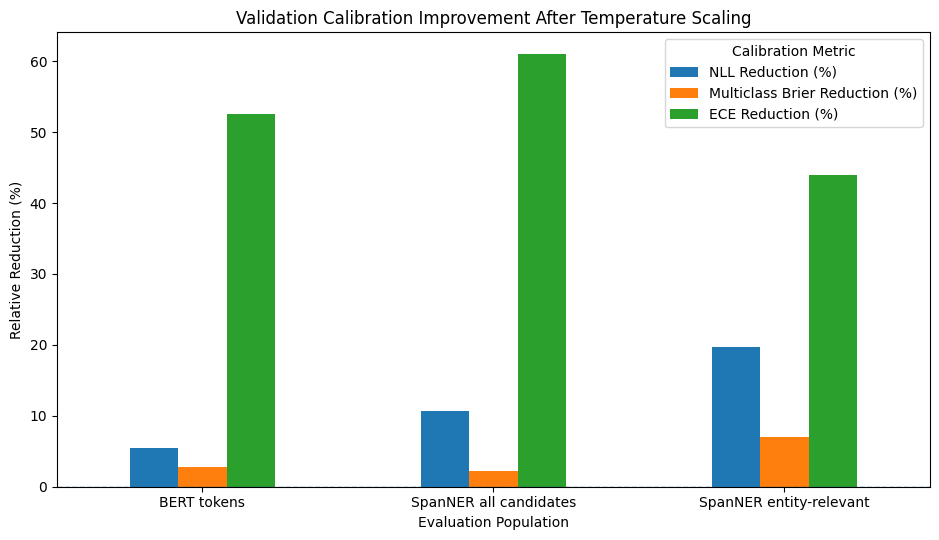

In [73]:
plot_metrics = [
    "NLL Reduction (%)",
    "Multiclass Brier Reduction (%)",
    "ECE Reduction (%)",
]


plot_df = (
    validation_calibration_improvement_df
    .set_index(
        "Population"
    )[
        plot_metrics
    ]
)


ax = plot_df.plot(
    kind="bar",
    figsize=(9.5, 5.5),
)

ax.set_title(
    "Validation Calibration Improvement After Temperature Scaling"
)

ax.set_xlabel(
    "Evaluation Population"
)

ax.set_ylabel(
    "Relative Reduction (%)"
)

ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

ax.tick_params(
    axis="x",
    rotation=0,
)

ax.legend(
    title="Calibration Metric"
)

plt.tight_layout()


temperature_improvement_figure_path = (
    FIGURE_DIR
    / "temperature_scaling_validation_improvement.png"
)

plt.savefig(
    temperature_improvement_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 5. Propagate Temperature-Scaled Probabilities to Span and Boundary Scores

Temperature scaling changes probability magnitudes but preserves the frozen predicted classes. The scaled probabilities can therefore be propagated to the already-emitted BERT BIO and SpanNER predictions without re-decoding either architecture.

For BERT BIO, temperature-scaled token probabilities are aggregated into typed-span confidence and architecture-specific boundary signals. The primary span confidence is the geometric mean of token-level maximum probabilities. Start-boundary uncertainty measures competition between the predicted entity type's beginning and continuation probabilities at the proposed start, while end-boundary uncertainty measures continuation evidence immediately after the proposed end.

For SpanNER, each frozen decoded span receives the temperature-scaled probability of its already-predicted entity type. Start and end boundary competition are then recomputed using the same frozen candidate universe and structural competitor definitions as Notebook 02.

These probability-derived features provide the inputs for binary correctness calibration in the following sections. Prediction identities, decoded spans and prediction-to-gold matching remain unchanged.

## 5.1 Output Directories and Shared Probability Diagnostics

In [74]:
BERT_TOKEN_OUTPUT_DIR = (
    BERT_PROBABILITY_DIR
    / "token_predictions"
)

BERT_SPAN_OUTPUT_DIR = (
    BERT_PROBABILITY_DIR
    / "span_features"
)

SPANNER_CANDIDATE_OUTPUT_DIR = (
    SPANNER_PROBABILITY_DIR
    / "candidate_predictions"
)

SPANNER_SPAN_OUTPUT_DIR = (
    SPANNER_PROBABILITY_DIR
    / "span_features"
)

BERT_EVENT_OUTPUT_DIR = (
    CALIBRATED_PREDICTION_DIR
    / "bert"
)

SPANNER_EVENT_OUTPUT_DIR = (
    CALIBRATED_PREDICTION_DIR
    / "spanner"
)


for directory in [
    BERT_TOKEN_OUTPUT_DIR,
    BERT_SPAN_OUTPUT_DIR,
    SPANNER_CANDIDATE_OUTPUT_DIR,
    SPANNER_SPAN_OUTPUT_DIR,
    BERT_EVENT_OUTPUT_DIR,
    SPANNER_EVENT_OUTPUT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


def probability_diagnostics(
    probabilities,
):
    """
    Derive maximum confidence, entropy and top-two
    probability margin from a multiclass distribution.
    """

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    confidence = np.max(
        probabilities,
        axis=1,
    )

    safe_probabilities = np.clip(
        probabilities,
        1e-15,
        1.0,
    )

    entropy = -np.sum(
        probabilities
        * np.log(
            safe_probabilities
        ),
        axis=1,
    )

    sorted_probabilities = np.sort(
        probabilities,
        axis=1,
    )

    margin = (
        sorted_probabilities[:, -1]
        - sorted_probabilities[:, -2]
    )

    return (
        confidence,
        entropy,
        margin,
    )


print(
    "Temperature-scaled span-feature propagation configured."
)

Temperature-scaled span-feature propagation configured.


## 5.2 BERT Temperature-Scaled Token Probabilities

In [75]:
BERT_LABEL_NAMES = [
    "O",
    "B_PER",
    "I_PER",
    "B_ORG",
    "I_ORG",
    "B_LOC",
    "I_LOC",
    "B_MISC",
    "I_MISC",
]

BERT_SCALED_PROBABILITY_COLUMNS = [
    f"temperature_scaled_prob_{label_name}"
    for label_name
    in BERT_LABEL_NAMES
]


bert_scaled_token_tables = {}


for split_name in CALIBRATION_SPLITS:
    token_table = (
        bert_token_tables[
            split_name
        ].copy()
    )

    scaled_probabilities = (
        bert_arrays[
            split_name
        ][
            "temperature_scaled_probabilities"
        ]
    )

    (
        confidence,
        entropy,
        margin,
    ) = probability_diagnostics(
        scaled_probabilities
    )

    scaled_predictions = np.argmax(
        scaled_probabilities,
        axis=1,
    ).astype(
        np.int64
    )

    frozen_predictions = pd.to_numeric(
        token_table[
            "predicted_label_id"
        ],
        errors="raise",
    ).to_numpy(
        dtype=np.int64
    )

    if not np.array_equal(
        scaled_predictions,
        frozen_predictions,
    ):
        raise RuntimeError(
            f"BERT predicted classes changed after "
            f"temperature scaling for {split_name}."
        )

    output_table = (
        token_table.copy()
    )

    output_table[
        "temperature"
    ] = bert_temperature

    for (
        column_index,
        column_name,
    ) in enumerate(
        BERT_SCALED_PROBABILITY_COLUMNS
    ):
        output_table[
            column_name
        ] = scaled_probabilities[
            :,
            column_index,
        ]

    output_table[
        "temperature_scaled_token_confidence"
    ] = confidence

    output_table[
        "temperature_scaled_token_entropy"
    ] = entropy

    output_table[
        "temperature_scaled_normalised_token_entropy"
    ] = (
        entropy
        / np.log(9)
    )

    output_table[
        "temperature_scaled_token_margin"
    ] = margin

    output_table.to_csv(
        BERT_TOKEN_OUTPUT_DIR
        / (
            f"{split_name}_"
            "temperature_scaled_token_predictions.csv"
        ),
        index=False,
    )

    bert_scaled_token_tables[
        split_name
    ] = output_table


print(
    "BERT temperature-scaled token probabilities propagated."
)

BERT temperature-scaled token probabilities propagated.


### 5.3 BERT Span Confidence and Boundary Features

Temperature-scaled BERT token probabilities are aggregated over each frozen emitted entity.

The primary typed-span confidence is the geometric mean of token-level maximum probabilities. The primary boundary features retain the architecture-specific BIO beginning/continuation definitions used throughout the dissertation.

A small set of previously defined contextual boundary-confidence measures is also retained as secondary sensitivity features. These do not replace the primary BIO-derived signals.

In [76]:
BIO_ENTITY_TYPES = {
    "PER",
    "ORG",
    "LOC",
    "MISC",
}

BOUNDARY_EPSILON = 1e-12


def build_bert_scaled_span_features(
    split_name,
):
    """
    Derive temperature-scaled BERT span confidence and
    architecture-specific boundary features without re-decoding.
    """

    span_table = pd.read_csv(
        BERT_ROOT
        / "span_predictions"
        / f"{split_name}_predicted_spans.csv",
        keep_default_na=False,
    ).copy()

    token_table = (
        bert_scaled_token_tables[
            split_name
        ]
    )

    sentence_token_tables = {
        int(sentence_index): (
            group
            .sort_values(
                "token_index"
            )
            .set_index(
                "token_index"
            )
        )
        for sentence_index, group
        in token_table.groupby(
            "sentence_index",
            sort=False,
        )
    }

    feature_rows = []

    for span in span_table.to_dict(
        orient="records"
    ):
        sentence_index = int(
            span[
                "sentence_index"
            ]
        )

        start = int(
            span[
                "start"
            ]
        )

        end = int(
            span[
                "end"
            ]
        )

        entity_type = str(
            span[
                "entity_type"
            ]
        )

        if (
            entity_type
            not in BIO_ENTITY_TYPES
        ):
            raise ValueError(
                f"Unexpected BERT entity type: {entity_type}"
            )

        sentence_tokens = (
            sentence_token_tables[
                sentence_index
            ]
        )

        span_tokens = sentence_tokens.loc[
            start:end
        ]

        confidence_values = (
            span_tokens[
                "temperature_scaled_token_confidence"
            ].to_numpy(
                dtype=float
            )
        )

        entropy_values = (
            span_tokens[
                "temperature_scaled_token_entropy"
            ].to_numpy(
                dtype=float
            )
        )

        normalised_entropy_values = (
            span_tokens[
                "temperature_scaled_normalised_token_entropy"
            ].to_numpy(
                dtype=float
            )
        )

        margin_values = (
            span_tokens[
                "temperature_scaled_token_margin"
            ].to_numpy(
                dtype=float
            )
        )

        geometric_confidence = float(
            np.exp(
                np.mean(
                    np.log(
                        np.clip(
                            confidence_values,
                            1e-15,
                            1.0,
                        )
                    )
                )
            )
        )

        beginning_column = (
            f"temperature_scaled_prob_B_{entity_type}"
        )

        continuation_column = (
            f"temperature_scaled_prob_I_{entity_type}"
        )

        start_row = sentence_tokens.loc[
            start
        ]

        end_row = sentence_tokens.loc[
            end
        ]

        start_beginning_probability = float(
            start_row[
                beginning_column
            ]
        )

        start_inside_probability = float(
            start_row[
                continuation_column
            ]
        )

        end_beginning_probability = float(
            end_row[
                beginning_column
            ]
        )

        end_inside_probability = float(
            end_row[
                continuation_column
            ]
        )

        # Primary architecture-specific start ambiguity.
        start_bio_uncertainty = (
            start_inside_probability
            / (
                start_beginning_probability
                + start_inside_probability
                + BOUNDARY_EPSILON
            )
        )

        next_index = (
            end + 1
        )

        if (
            next_index
            in sentence_tokens.index
        ):
            next_inside_probability = float(
                sentence_tokens.loc[
                    next_index,
                    continuation_column,
                ]
            )
        else:
            # A sentence-final entity cannot continue beyond
            # the available sequence.
            next_inside_probability = 0.0

        end_bio_uncertainty = (
            next_inside_probability
        )

        joint_bio_uncertainty = max(
            start_bio_uncertainty,
            end_bio_uncertainty,
        )

        # Secondary contextual boundary-confidence features.
        previous_index = (
            start - 1
        )

        if (
            previous_index
            in sentence_tokens.index
        ):
            previous_inside_probability = float(
                sentence_tokens.loc[
                    previous_index,
                    continuation_column,
                ]
            )
        else:
            previous_inside_probability = 0.0

        previous_noncontinuation = (
            1.0
            - previous_inside_probability
        )

        end_entity_membership = (
            end_beginning_probability
            + end_inside_probability
        )

        end_stopping_confidence = (
            1.0
            - next_inside_probability
        )

        contextual_start_confidence = (
            start_beginning_probability
            * previous_noncontinuation
        )

        contextual_end_confidence = (
            end_entity_membership
            * end_stopping_confidence
        )

        contextual_joint_min = min(
            contextual_start_confidence,
            contextual_end_confidence,
        )

        feature_rows.append({
            "temperature_scaled_start_token_confidence": float(
                confidence_values[0]
            ),
            "temperature_scaled_end_token_confidence": float(
                confidence_values[-1]
            ),
            "temperature_scaled_span_min_confidence": float(
                confidence_values.min()
            ),
            "temperature_scaled_span_mean_confidence": float(
                confidence_values.mean()
            ),
            "temperature_scaled_span_geometric_confidence": (
                geometric_confidence
            ),
            "temperature_scaled_span_mean_entropy": float(
                entropy_values.mean()
            ),
            "temperature_scaled_span_max_entropy": float(
                entropy_values.max()
            ),
            "temperature_scaled_span_mean_normalised_entropy": float(
                normalised_entropy_values.mean()
            ),
            "temperature_scaled_span_max_normalised_entropy": float(
                normalised_entropy_values.max()
            ),
            "temperature_scaled_span_min_margin": float(
                margin_values.min()
            ),
            "temperature_scaled_span_mean_margin": float(
                margin_values.mean()
            ),

            # Primary BERT boundary uncertainties.
            "temperature_scaled_start_bio_boundary_uncertainty": (
                start_bio_uncertainty
            ),
            "temperature_scaled_end_bio_continuation_uncertainty": (
                end_bio_uncertainty
            ),
            "temperature_scaled_joint_bio_boundary_uncertainty": (
                joint_bio_uncertainty
            ),

            # Confidence orientation used by binary calibration.
            "score_start_bio_confidence": (
                1.0
                - start_bio_uncertainty
            ),
            "score_end_bio_confidence": (
                1.0
                - end_bio_uncertainty
            ),
            "score_joint_bio_confidence": (
                1.0
                - joint_bio_uncertainty
            ),

            # Secondary contextual sensitivity features.
            "temperature_scaled_context_start_boundary_score": (
                contextual_start_confidence
            ),
            "temperature_scaled_context_end_boundary_score": (
                contextual_end_confidence
            ),
            "temperature_scaled_joint_boundary_score_min": (
                contextual_joint_min
            ),
        })

    feature_df = pd.DataFrame(
        feature_rows
    )

    if (
        len(feature_df)
        != len(span_table)
    ):
        raise RuntimeError(
            f"BERT span feature count mismatch for {split_name}."
        )

    output_table = pd.concat(
        [
            span_table.reset_index(
                drop=True
            ),
            feature_df.reset_index(
                drop=True
            ),
        ],
        axis=1,
    )

    output_table[
        "temperature"
    ] = bert_temperature

    return output_table


bert_scaled_span_tables = {
    split_name: (
        build_bert_scaled_span_features(
            split_name
        )
    )
    for split_name
    in CALIBRATION_SPLITS
}


for (
    split_name,
    output_table,
) in bert_scaled_span_tables.items():
    output_table.to_csv(
        BERT_SPAN_OUTPUT_DIR
        / (
            f"{split_name}_"
            "temperature_scaled_span_boundary_features.csv"
        ),
        index=False,
    )


print(
    "BERT temperature-scaled span and boundary features saved."
)

BERT temperature-scaled span and boundary features saved.


### 5.4 Span model Candidate and Span Probabilities

The fitted Span model temperature is applied to every frozen five-class candidate.

Each already-decoded entity span then receives the temperature-scaled probability corresponding to its frozen predicted entity type. No candidate label is changed and the decoder is not rerun.

In [77]:
SPANNER_SCALED_PROBABILITY_COLUMNS = [
    f"temperature_scaled_probability_{label_name}"
    for label_name
    in SPANNER_LABELS
]


spanner_scaled_candidate_tables = {}


for split_name in CALIBRATION_SPLITS:
    candidate_table = (
        spanner_candidate_tables[
            split_name
        ].copy()
    )

    scaled_probabilities = (
        spanner_arrays[
            split_name
        ][
            "temperature_scaled_probabilities"
        ]
    )

    (
        confidence,
        entropy,
        margin,
    ) = probability_diagnostics(
        scaled_probabilities
    )

    scaled_predictions = np.argmax(
        scaled_probabilities,
        axis=1,
    ).astype(
        np.int64
    )

    frozen_predictions = pd.to_numeric(
        candidate_table[
            "predicted_label_id"
        ],
        errors="raise",
    ).to_numpy(
        dtype=np.int64
    )

    if not np.array_equal(
        scaled_predictions,
        frozen_predictions,
    ):
        raise RuntimeError(
            f"SpanNER predicted classes changed after "
            f"temperature scaling for {split_name}."
        )

    output_table = (
        candidate_table.copy()
    )

    output_table[
        "temperature"
    ] = spanner_temperature

    for (
        column_index,
        column_name,
    ) in enumerate(
        SPANNER_SCALED_PROBABILITY_COLUMNS
    ):
        output_table[
            column_name
        ] = scaled_probabilities[
            :,
            column_index,
        ]

    output_table[
        "temperature_scaled_confidence"
    ] = confidence

    output_table[
        "temperature_scaled_entropy"
    ] = entropy

    output_table[
        "temperature_scaled_normalised_entropy"
    ] = (
        entropy
        / np.log(5)
    )

    output_table[
        "temperature_scaled_margin"
    ] = margin

    output_table[
        "temperature_scaled_confidence_uncertainty"
    ] = (
        1.0
        - confidence
    )

    output_table[
        "temperature_scaled_margin_uncertainty"
    ] = (
        1.0
        - margin
    )

    output_table.to_csv(
        SPANNER_CANDIDATE_OUTPUT_DIR
        / (
            f"{split_name}_"
            "temperature_scaled_candidate_predictions.csv"
        ),
        index=False,
    )

    spanner_scaled_candidate_tables[
        split_name
    ] = output_table


spanner_scaled_span_tables = {}


for split_name in CALIBRATION_SPLITS:
    decoded_table = pd.read_csv(
        SPANNER_ROOT
        / "span_predictions"
        / f"{split_name}_predicted_spans.csv",
        keep_default_na=False,
    ).copy()

    candidate_table = (
        spanner_scaled_candidate_tables[
            split_name
        ].copy()
    )

    join_keys = [
        "source_index",
        "sentence_index",
        "candidate_index",
    ]

    for dataframe in [
        decoded_table,
        candidate_table,
    ]:
        for key in join_keys:
            dataframe[
                key
            ] = pd.to_numeric(
                dataframe[
                    key
                ],
                errors="raise",
            ).astype(int)

    candidate_feature_columns = [
        *join_keys,
        "temperature_scaled_confidence",
        "temperature_scaled_entropy",
        "temperature_scaled_normalised_entropy",
        "temperature_scaled_margin",
        "temperature_scaled_confidence_uncertainty",
        "temperature_scaled_margin_uncertainty",
        *SPANNER_SCALED_PROBABILITY_COLUMNS,
        "temperature",
    ]

    output_table = (
        decoded_table.merge(
            candidate_table[
                candidate_feature_columns
            ],
            on=join_keys,
            how="left",
            validate="one_to_one",
        )
    )

    scaled_span_probabilities = []

    for row in output_table.to_dict(
        orient="records"
    ):
        entity_type = str(
            row[
                "entity_type"
            ]
        )

        probability_column = (
            f"temperature_scaled_probability_{entity_type}"
        )

        scaled_span_probabilities.append(
            float(
                row[
                    probability_column
                ]
            )
        )

    output_table[
        "temperature_scaled_span_probability"
    ] = scaled_span_probabilities

    output_table[
        "temperature_scaled_span_probability_uncertainty"
    ] = (
        1.0
        - output_table[
            "temperature_scaled_span_probability"
        ]
    )

    output_table.to_csv(
        SPANNER_SPAN_OUTPUT_DIR
        / (
            f"{split_name}_"
            "temperature_scaled_predicted_spans.csv"
        ),
        index=False,
    )

    spanner_scaled_span_tables[
        split_name
    ] = output_table


print(
    "SpanNER temperature-scaled candidate and span probabilities saved."
)

print(
    "SpanNER decoder rerun:",
    False,
)

SpanNER temperature-scaled candidate and span probabilities saved.
SpanNER decoder rerun: False


## 5.5 SpanNER Boundary Competition After Temperature Scaling

In [78]:
def calculate_scaled_boundary_competition(
    candidate_table,
    decoded_table,
):
    """
    Recompute SpanNER local boundary competition from
    temperature-scaled probabilities while preserving
    the frozen candidate and decoded-span populations.
    """

    competition_rows = []

    candidates_by_sentence = {
        (
            int(source_index),
            int(sentence_index),
        ): group.copy()

        for (
            source_index,
            sentence_index,
        ), group

        in candidate_table.groupby(
            [
                "source_index",
                "sentence_index",
            ],
            sort=False,
        )
    }

    for prediction in decoded_table.to_dict(
        orient="records"
    ):
        source_index = int(
            prediction[
                "source_index"
            ]
        )

        sentence_index = int(
            prediction[
                "sentence_index"
            ]
        )

        candidate_index = int(
            prediction[
                "candidate_index"
            ]
        )

        predicted_start = int(
            prediction[
                "start"
            ]
        )

        predicted_end = int(
            prediction[
                "end"
            ]
        )

        predicted_type = str(
            prediction[
                "entity_type"
            ]
        )

        sentence_candidates = (
            candidates_by_sentence[
                (
                    source_index,
                    sentence_index,
                )
            ]
        )

        probability_column = (
            f"temperature_scaled_probability_{predicted_type}"
        )

        selected_row = (
            sentence_candidates.loc[
                sentence_candidates[
                    "candidate_index"
                ].eq(
                    candidate_index
                )
            ]
        )

        if len(selected_row) != 1:
            raise RuntimeError(
                "Unable to identify the frozen selected SpanNER candidate."
            )

        selected_probability = float(
            selected_row.iloc[0][
                probability_column
            ]
        )

        start_competitors = (
            sentence_candidates.loc[
                sentence_candidates[
                    "end"
                ].eq(
                    predicted_end
                )
                & ~sentence_candidates[
                    "start"
                ].eq(
                    predicted_start
                )
            ]
        )

        end_competitors = (
            sentence_candidates.loc[
                sentence_candidates[
                    "start"
                ].eq(
                    predicted_start
                )
                & ~sentence_candidates[
                    "end"
                ].eq(
                    predicted_end
                )
            ]
        )

        if len(
            start_competitors
        ):
            best_start_row = (
                start_competitors.loc[
                    start_competitors[
                        probability_column
                    ].idxmax()
                ]
            )

            start_competitor_probability = float(
                best_start_row[
                    probability_column
                ]
            )

            start_uncertainty = (
                start_competitor_probability
                / (
                    selected_probability
                    + start_competitor_probability
                    + BOUNDARY_EPSILON
                )
            )
        else:
            start_competitor_probability = (
                np.nan
            )

            start_uncertainty = (
                np.nan
            )

        if len(
            end_competitors
        ):
            best_end_row = (
                end_competitors.loc[
                    end_competitors[
                        probability_column
                    ].idxmax()
                ]
            )

            end_competitor_probability = float(
                best_end_row[
                    probability_column
                ]
            )

            end_uncertainty = (
                end_competitor_probability
                / (
                    selected_probability
                    + end_competitor_probability
                    + BOUNDARY_EPSILON
                )
            )
        else:
            end_competitor_probability = (
                np.nan
            )

            end_uncertainty = (
                np.nan
            )

        available_boundary_values = [
            value
            for value
            in [
                start_uncertainty,
                end_uncertainty,
            ]
            if pd.notna(
                value
            )
        ]

        joint_uncertainty = (
            max(
                available_boundary_values
            )
            if available_boundary_values
            else np.nan
        )

        competition_rows.append({
            "source_index": (
                source_index
            ),
            "sentence_index": (
                sentence_index
            ),
            "candidate_index": (
                candidate_index
            ),

            "temperature_scaled_selected_probability": (
                selected_probability
            ),

            "temperature_scaled_start_competitor_probability": (
                start_competitor_probability
            ),

            "temperature_scaled_start_boundary_competition_uncertainty": (
                start_uncertainty
            ),

            "temperature_scaled_end_competitor_probability": (
                end_competitor_probability
            ),

            "temperature_scaled_end_boundary_competition_uncertainty": (
                end_uncertainty
            ),

            "temperature_scaled_joint_boundary_competition_uncertainty": (
                joint_uncertainty
            ),
        })

    return pd.DataFrame(
        competition_rows
    )


spanner_scaled_boundary_tables = {}


for split_name in CALIBRATION_SPLITS:
    boundary_table = (
        calculate_scaled_boundary_competition(
            candidate_table=(
                spanner_scaled_candidate_tables[
                    split_name
                ]
            ),
            decoded_table=(
                spanner_scaled_span_tables[
                    split_name
                ]
            ),
        )
    )

    if (
        len(boundary_table)
        != len(
            spanner_scaled_span_tables[
                split_name
            ]
        )
    ):
        raise RuntimeError(
            f"SpanNER boundary-feature count mismatch for {split_name}."
        )

    # Convert uncertainty to correctness-oriented confidence.
    boundary_table[
        "score_start_competition_confidence"
    ] = (
        1.0
        - boundary_table[
            "temperature_scaled_start_boundary_competition_uncertainty"
        ]
    )

    boundary_table[
        "score_end_competition_confidence"
    ] = (
        1.0
        - boundary_table[
            "temperature_scaled_end_boundary_competition_uncertainty"
        ]
    )

    boundary_table[
        "score_joint_competition_confidence"
    ] = (
        1.0
        - boundary_table[
            "temperature_scaled_joint_boundary_competition_uncertainty"
        ]
    )

    spanner_scaled_boundary_tables[
        split_name
    ] = boundary_table


print(
    "SpanNER temperature-scaled boundary competition recomputed."
)

print(
    "Missing competitor values imputed:",
    False,
)

SpanNER temperature-scaled boundary competition recomputed.
Missing competitor values imputed: False


## 5.6 Attach Frozen Correctness Labels

In [79]:
bert_prediction_event_tables = {}
spanner_prediction_event_tables = {}


# BERT
for split_name in CALIBRATION_SPLITS:
    matching_table = (
        bert_matching_tables[
            split_name
        ].copy()
    )

    # Gold-only false-negative rows do not correspond to emitted
    # predictions and therefore have no prediction confidence.
    prediction_events = (
        matching_table.loc[
            matching_table[
                "predicted_start"
            ].notna()
        ]
        .copy()
    )

    feature_table = (
        bert_scaled_span_tables[
            split_name
        ].copy()
    )

    feature_lookup = (
        feature_table.rename(
            columns={
                "start": (
                    "predicted_start"
                ),
                "end": (
                    "predicted_end"
                ),
                "entity_type": (
                    "predicted_entity_type"
                ),
            }
        )
    )

    join_keys = [
        "source_index",
        "sentence_index",
        "predicted_start",
        "predicted_end",
        "predicted_entity_type",
    ]

    for dataframe in [
        prediction_events,
        feature_lookup,
    ]:
        for column_name in [
            "source_index",
            "sentence_index",
            "predicted_start",
            "predicted_end",
        ]:
            dataframe[
                column_name
            ] = pd.to_numeric(
                dataframe[
                    column_name
                ],
                errors="raise",
            ).astype(int)

    bert_feature_columns = [
        *join_keys,

        "temperature_scaled_span_min_confidence",
        "temperature_scaled_span_mean_confidence",
        "temperature_scaled_span_geometric_confidence",
        "temperature_scaled_span_mean_margin",

        "temperature_scaled_start_bio_boundary_uncertainty",
        "temperature_scaled_end_bio_continuation_uncertainty",
        "temperature_scaled_joint_bio_boundary_uncertainty",

        "score_start_bio_confidence",
        "score_end_bio_confidence",
        "score_joint_bio_confidence",

        "temperature_scaled_context_start_boundary_score",
        "temperature_scaled_context_end_boundary_score",
        "temperature_scaled_joint_boundary_score_min",

        "temperature",
    ]

    output_table = (
        prediction_events.merge(
            feature_lookup[
                bert_feature_columns
            ],
            on=join_keys,
            how="left",
            validate="one_to_one",
        )
    )

    if (
        output_table[
            "temperature"
        ].isna().any()
    ):
        raise RuntimeError(
            f"Missing BERT scaled features after merge for {split_name}."
        )

    output_table.to_csv(
        BERT_EVENT_OUTPUT_DIR
        / (
            f"{split_name}_"
            "temperature_scaled_prediction_events.csv"
        ),
        index=False,
    )

    bert_prediction_event_tables[
        split_name
    ] = output_table


# SpanNER
for split_name in CALIBRATION_SPLITS:
    matching_table = (
        spanner_matching_tables[
            split_name
        ].copy()
    )

    prediction_events = (
        matching_table.loc[
            matching_table[
                "predicted_candidate_index"
            ].notna()
        ]
        .copy()
    )

    prediction_events[
        "candidate_index"
    ] = pd.to_numeric(
        prediction_events[
            "predicted_candidate_index"
        ],
        errors="raise",
    ).astype(int)

    span_features = (
        spanner_scaled_span_tables[
            split_name
        ].copy()
    )

    boundary_features = (
        spanner_scaled_boundary_tables[
            split_name
        ].copy()
    )

    join_keys = [
        "source_index",
        "sentence_index",
        "candidate_index",
    ]

    for dataframe in [
        prediction_events,
        span_features,
        boundary_features,
    ]:
        for key in join_keys:
            dataframe[
                key
            ] = pd.to_numeric(
                dataframe[
                    key
                ],
                errors="raise",
            ).astype(int)

    span_feature_columns = [
        *join_keys,
        "temperature_scaled_span_probability",
        "temperature_scaled_span_probability_uncertainty",
        "temperature_scaled_confidence",
        "temperature_scaled_entropy",
        "temperature_scaled_normalised_entropy",
        "temperature_scaled_margin",
        "temperature",
    ]

    boundary_feature_columns = [
        *join_keys,

        "temperature_scaled_selected_probability",

        "temperature_scaled_start_competitor_probability",
        "temperature_scaled_start_boundary_competition_uncertainty",
        "score_start_competition_confidence",

        "temperature_scaled_end_competitor_probability",
        "temperature_scaled_end_boundary_competition_uncertainty",
        "score_end_competition_confidence",

        "temperature_scaled_joint_boundary_competition_uncertainty",
        "score_joint_competition_confidence",
    ]

    output_table = (
        prediction_events
        .merge(
            span_features[
                span_feature_columns
            ],
            on=join_keys,
            how="left",
            validate="one_to_one",
        )
        .merge(
            boundary_features[
                boundary_feature_columns
            ],
            on=join_keys,
            how="left",
            validate="one_to_one",
        )
    )

    if (
        output_table[
            "temperature"
        ].isna().any()
    ):
        raise RuntimeError(
            f"Missing SpanNER scaled span features after merge "
            f"for {split_name}."
        )

    output_table.to_csv(
        SPANNER_EVENT_OUTPUT_DIR
        / (
            f"{split_name}_"
            "temperature_scaled_prediction_events.csv"
        ),
        index=False,
    )

    spanner_prediction_event_tables[
        split_name
    ] = output_table


print(
    "Frozen correctness labels attached to temperature-scaled features."
)

print(
    "Prediction–gold matching recomputed:",
    False,
)

Frozen correctness labels attached to temperature-scaled features.
Prediction–gold matching recomputed: False


## 5.7 Propagated Feature Summary

In [80]:
propagation_summary_records = []


for split_name in CALIBRATION_SPLITS:
    bert_table = (
        bert_prediction_event_tables[
            split_name
        ]
    )

    spanner_table = (
        spanner_prediction_event_tables[
            split_name
        ]
    )

    propagation_summary_records.extend([
        {
            "Model": (
                "BERT BIO"
            ),
            "Population": (
                split_name
            ),
            "Prediction Events": int(
                len(
                    bert_table
                )
            ),
            "Start Boundary Score Available": int(
                bert_table[
                    "score_start_bio_confidence"
                ]
                .notna()
                .sum()
            ),
            "End Boundary Score Available": int(
                bert_table[
                    "score_end_bio_confidence"
                ]
                .notna()
                .sum()
            ),
            "Joint Boundary Score Available": int(
                bert_table[
                    "score_joint_bio_confidence"
                ]
                .notna()
                .sum()
            ),
        },
        {
            "Model": (
                "SpanNER"
            ),
            "Population": (
                split_name
            ),
            "Prediction Events": int(
                len(
                    spanner_table
                )
            ),
            "Start Boundary Score Available": int(
                spanner_table[
                    "score_start_competition_confidence"
                ]
                .notna()
                .sum()
            ),
            "End Boundary Score Available": int(
                spanner_table[
                    "score_end_competition_confidence"
                ]
                .notna()
                .sum()
            ),
            "Joint Boundary Score Available": int(
                spanner_table[
                    "score_joint_competition_confidence"
                ]
                .notna()
                .sum()
            ),
        },
    ])


propagation_summary_df = pd.DataFrame(
    propagation_summary_records
)


propagation_summary_df.to_csv(
    METRICS_DIR
    / "temperature_scaled_feature_propagation_summary.csv",
    index=False,
)


print(
    "Temperature-scaled prediction features:"
)

display(
    propagation_summary_df
)

Temperature-scaled prediction features:


,Model,Population,Prediction Events,Start Boundary Score Available,End Boundary Score Available,Joint Boundary Score Available
0,BERT BIO,probability_calibration,1771,1771,1771,1771
1,SpanNER,probability_calibration,1760,1467,1741,1759
2,BERT BIO,validation,3039,3039,3039,3039
3,SpanNER,validation,2978,2470,2946,2976


## 6. Construct Binary Correctness-Calibration Populations

Binary calibration predicts whether a frozen prediction event is correct.

Four event types are defined:

- **exact entity correctness:** the emitted prediction has the correct start boundary, end boundary and entity type;
- **start-boundary correctness:** the matched prediction has the correct start boundary;
- **end-boundary correctness:** the matched prediction has the correct end boundary;
- **joint-boundary correctness:** both boundaries of the matched prediction are correct.

Exact-entity calibration uses all emitted predictions, including unmatched false positives, which are incorrect exact-entity events.

Boundary calibration uses only frozen prediction–gold matched pairs. Unmatched predictions are not assigned artificial boundary-correctness labels because boundary localisation is evaluated separately from whether the prediction corresponds to a gold entity at all.

Natural correctness and error prevalence are preserved. No class weighting, resampling or synthetic boundary errors are introduced.

For SpanNER's architecture-specific boundary-competition scores, matched predictions without a valid structural competitor remain unavailable for that score-specific analysis. Missing competition is not interpreted as perfect confidence.

## 6.1 Standardise the Four Correctness Targets

In [81]:
EVENT_POPULATION_DIR = (
    OUTPUT_DIR
    / "event_populations"
)

EVENT_POPULATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def parse_nullable_boolean(
    series,
):
    """Parse boolean CSV values while preserving genuine missingness."""

    mapping = {
        True: True,
        False: False,
        "True": True,
        "False": False,
        "true": True,
        "false": False,
        1: True,
        0: False,
        "1": True,
        "0": False,
        "": pd.NA,
        None: pd.NA,
    }

    converted = series.map(
        mapping
    )

    original_missing = (
        series.isna()
        | series.astype(str).eq("")
    )

    unparsed = (
        converted.isna()
        & ~original_missing
    )

    if unparsed.any():
        unexpected = (
            series.loc[
                unparsed
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            "Unexpected boolean value(s): "
            f"{unexpected}"
        )

    return converted.astype(
        "boolean"
    )


TARGET_COLUMNS = {
    "exact_entity": (
        "target_exact_correct"
    ),
    "start_boundary": (
        "target_start_correct"
    ),
    "end_boundary": (
        "target_end_correct"
    ),
    "joint_boundary": (
        "target_joint_correct"
    ),
}


MODEL_EVENT_TABLES = {
    "BERT": (
        bert_prediction_event_tables
    ),
    "SpanNER": (
        spanner_prediction_event_tables
    ),
}


standardised_event_tables = {
    "BERT": {},
    "SpanNER": {},
}


for model_name in [
    "BERT",
    "SpanNER",
]:
    for split_name in (
        CALIBRATION_SPLITS
    ):
        dataframe = (
            MODEL_EVENT_TABLES[
                model_name
            ][
                split_name
            ]
            .copy()
        )

        for column_name in [
            "is_exact_correct",
            "is_start_correct",
            "is_end_correct",
            "is_boundary_correct",
        ]:
            dataframe[
                column_name
            ] = parse_nullable_boolean(
                dataframe[
                    column_name
                ]
            )

        dataframe[
            "source_index"
        ] = pd.to_numeric(
            dataframe[
                "source_index"
            ],
            errors="raise",
        ).astype(int)

        dataframe[
            "sentence_index"
        ] = pd.to_numeric(
            dataframe[
                "sentence_index"
            ],
            errors="raise",
        ).astype(int)

        # Every emitted prediction has an exact-entity outcome.
        dataframe[
            "target_exact_correct"
        ] = (
            dataframe[
                "is_exact_correct"
            ]
            .astype(int)
        )

        # Boundary-localisation events are defined only for the
        # frozen matched prediction–gold population.
        matched_mask = dataframe[
            "row_source"
        ].eq(
            "matched_pair"
        )

        for (
            target_column,
            correctness_column,
        ) in [
            (
                "target_start_correct",
                "is_start_correct",
            ),
            (
                "target_end_correct",
                "is_end_correct",
            ),
            (
                "target_joint_correct",
                "is_boundary_correct",
            ),
        ]:
            dataframe[
                target_column
            ] = np.nan

            dataframe.loc[
                matched_mask,
                target_column,
            ] = (
                dataframe.loc[
                    matched_mask,
                    correctness_column,
                ]
                .astype(int)
                .astype(float)
            )

        standardised_event_tables[
            model_name
        ][
            split_name
        ] = dataframe


print(
    "Binary correctness targets constructed."
)

print(
    "Prediction–gold matching recomputed:",
    False,
)

Binary correctness targets constructed.
Prediction–gold matching recomputed: False


## 6.2 Natural Correctness and Error Prevalence

In [82]:
event_population_records = []


for model_name in [
    "BERT",
    "SpanNER",
]:
    for split_name in (
        CALIBRATION_SPLITS
    ):
        dataframe = (
            standardised_event_tables[
                model_name
            ][
                split_name
            ]
        )

        for (
            event_name,
            target_column,
        ) in TARGET_COLUMNS.items():
            event_values = (
                dataframe[
                    target_column
                ]
                .dropna()
                .astype(int)
            )

            number_events = int(
                len(
                    event_values
                )
            )

            number_correct = int(
                event_values.sum()
            )

            number_errors = int(
                number_events
                - number_correct
            )

            event_population_records.append({
                "Model": (
                    model_name
                ),
                "Population": (
                    split_name
                ),
                "Event": (
                    event_name
                ),
                "Rows": (
                    number_events
                ),
                "Correct": (
                    number_correct
                ),
                "Errors": (
                    number_errors
                ),
                "Correctness Prevalence": (
                    number_correct
                    / number_events
                ),
                "Error Prevalence": (
                    number_errors
                    / number_events
                ),
            })


event_population_df = pd.DataFrame(
    event_population_records
)


event_population_df.to_csv(
    EVENT_POPULATION_DIR
    / "natural_binary_event_populations.csv",
    index=False,
)


print(
    "Natural binary correctness-event populations:"
)

display(
    event_population_df.round(
        6
    )
)

print(
    "\nClass weighting used:",
    False,
)

print(
    "Resampling used:",
    False,
)

print(
    "Synthetic boundary errors created:",
    False,
)

Natural binary correctness-event populations:


,Model,Population,Event,Rows,Correct,Errors,Correctness Prevalence,Error Prevalence
0,BERT,probability_calibration,exact_entity,1771,1652,119,0.932806,0.067194
1,BERT,probability_calibration,start_boundary,1734,1720,14,0.991926,0.008074
2,BERT,probability_calibration,end_boundary,1734,1716,18,0.989619,0.010381
3,BERT,probability_calibration,joint_boundary,1734,1703,31,0.982122,0.017878
4,BERT,validation,exact_entity,3039,2859,180,0.940770,0.059230
5,BERT,validation,start_boundary,2981,2958,23,0.992284,0.007716
6,BERT,validation,end_boundary,2981,2952,29,0.990272,0.009728
7,BERT,validation,joint_boundary,2981,2931,50,0.983227,0.016773
8,SpanNER,probability_calibration,exact_entity,1760,1647,113,0.935795,0.064205
9,SpanNER,probability_calibration,start_boundary,1729,1716,13,0.992481,0.007519



Class weighting used: False
Resampling used: False
Synthetic boundary errors created: False


### 6.3 Pre-Specified Binary Calibration Scores

The binary calibration inputs are fixed before any logistic mapping is fitted.

The primary architecture-specific scores are:

| Architecture | Event | Primary input |
|---|---|---|
| BERT BIO | Exact entity | Geometric typed-span confidence |
| BERT BIO | Start boundary | BIO start-boundary confidence |
| BERT BIO | End boundary | BIO end-stopping confidence |
| BERT BIO | Joint boundary | Joint BIO boundary confidence |
| SpanNER | Exact entity | Direct span probability |
| SpanNER | Start boundary | Start boundary-competition confidence |
| SpanNER | End boundary | End boundary-competition confidence |
| SpanNER | Joint boundary | Joint boundary-competition confidence |

Previously defined contextual BERT measures and universally available SpanNER span probability are retained only as sensitivity analyses. They do not replace the predefined architecture-native primary configurations.

In [83]:
score_registry_df = pd.DataFrame([
    # BERT exact-entity calibration.
    {
        "Calibrator ID": (
            "bert_exact_geometric"
        ),
        "Model": "BERT",
        "Event": "exact_entity",
        "Target Column": (
            "target_exact_correct"
        ),
        "Score Column": (
            "temperature_scaled_span_geometric_confidence"
        ),
        "Display Name": (
            "Geometric BIO span confidence"
        ),
        "Analysis Role": "primary",
        "Population Policy": (
            "all_emitted_predictions"
        ),
        "C": EXACT_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "bert_exact_min_confidence"
        ),
        "Model": "BERT",
        "Event": "exact_entity",
        "Target Column": (
            "target_exact_correct"
        ),
        "Score Column": (
            "temperature_scaled_span_min_confidence"
        ),
        "Display Name": (
            "Minimum token confidence"
        ),
        "Analysis Role": (
            "sensitivity"
        ),
        "Population Policy": (
            "all_emitted_predictions"
        ),
        "C": EXACT_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "bert_exact_mean_margin"
        ),
        "Model": "BERT",
        "Event": "exact_entity",
        "Target Column": (
            "target_exact_correct"
        ),
        "Score Column": (
            "temperature_scaled_span_mean_margin"
        ),
        "Display Name": (
            "Mean token margin"
        ),
        "Analysis Role": (
            "sensitivity"
        ),
        "Population Policy": (
            "all_emitted_predictions"
        ),
        "C": EXACT_CALIBRATION_C,
    },

    # BERT boundary calibration.
    {
        "Calibrator ID": (
            "bert_start_bio"
        ),
        "Model": "BERT",
        "Event": "start_boundary",
        "Target Column": (
            "target_start_correct"
        ),
        "Score Column": (
            "score_start_bio_confidence"
        ),
        "Display Name": (
            "BIO start-boundary confidence"
        ),
        "Analysis Role": "primary",
        "Population Policy": (
            "matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "bert_start_context"
        ),
        "Model": "BERT",
        "Event": "start_boundary",
        "Target Column": (
            "target_start_correct"
        ),
        "Score Column": (
            "temperature_scaled_context_start_boundary_score"
        ),
        "Display Name": (
            "Contextual start-boundary confidence"
        ),
        "Analysis Role": (
            "sensitivity"
        ),
        "Population Policy": (
            "matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "bert_end_bio"
        ),
        "Model": "BERT",
        "Event": "end_boundary",
        "Target Column": (
            "target_end_correct"
        ),
        "Score Column": (
            "score_end_bio_confidence"
        ),
        "Display Name": (
            "BIO end-stopping confidence"
        ),
        "Analysis Role": "primary",
        "Population Policy": (
            "matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "bert_end_context"
        ),
        "Model": "BERT",
        "Event": "end_boundary",
        "Target Column": (
            "target_end_correct"
        ),
        "Score Column": (
            "temperature_scaled_context_end_boundary_score"
        ),
        "Display Name": (
            "Contextual end-boundary confidence"
        ),
        "Analysis Role": (
            "sensitivity"
        ),
        "Population Policy": (
            "matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "bert_joint_bio"
        ),
        "Model": "BERT",
        "Event": "joint_boundary",
        "Target Column": (
            "target_joint_correct"
        ),
        "Score Column": (
            "score_joint_bio_confidence"
        ),
        "Display Name": (
            "Joint BIO boundary confidence"
        ),
        "Analysis Role": "primary",
        "Population Policy": (
            "matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "bert_joint_context_min"
        ),
        "Model": "BERT",
        "Event": "joint_boundary",
        "Target Column": (
            "target_joint_correct"
        ),
        "Score Column": (
            "temperature_scaled_joint_boundary_score_min"
        ),
        "Display Name": (
            "Contextual joint minimum confidence"
        ),
        "Analysis Role": (
            "sensitivity"
        ),
        "Population Policy": (
            "matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },

    # SpanNER exact-entity calibration.
    {
        "Calibrator ID": (
            "spanner_exact_direct"
        ),
        "Model": "SpanNER",
        "Event": "exact_entity",
        "Target Column": (
            "target_exact_correct"
        ),
        "Score Column": (
            "temperature_scaled_span_probability"
        ),
        "Display Name": (
            "Direct span probability"
        ),
        "Analysis Role": "primary",
        "Population Policy": (
            "all_emitted_predictions"
        ),
        "C": EXACT_CALIBRATION_C,
    },

    # SpanNER boundary calibration.
    {
        "Calibrator ID": (
            "spanner_start_competition"
        ),
        "Model": "SpanNER",
        "Event": "start_boundary",
        "Target Column": (
            "target_start_correct"
        ),
        "Score Column": (
            "score_start_competition_confidence"
        ),
        "Display Name": (
            "Start boundary competition confidence"
        ),
        "Analysis Role": "primary",
        "Population Policy": (
            "competitor_available_matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "spanner_start_direct"
        ),
        "Model": "SpanNER",
        "Event": "start_boundary",
        "Target Column": (
            "target_start_correct"
        ),
        "Score Column": (
            "temperature_scaled_span_probability"
        ),
        "Display Name": (
            "Direct span probability"
        ),
        "Analysis Role": (
            "sensitivity"
        ),
        "Population Policy": (
            "matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "spanner_end_competition"
        ),
        "Model": "SpanNER",
        "Event": "end_boundary",
        "Target Column": (
            "target_end_correct"
        ),
        "Score Column": (
            "score_end_competition_confidence"
        ),
        "Display Name": (
            "End boundary competition confidence"
        ),
        "Analysis Role": "primary",
        "Population Policy": (
            "competitor_available_matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "spanner_end_direct"
        ),
        "Model": "SpanNER",
        "Event": "end_boundary",
        "Target Column": (
            "target_end_correct"
        ),
        "Score Column": (
            "temperature_scaled_span_probability"
        ),
        "Display Name": (
            "Direct span probability"
        ),
        "Analysis Role": (
            "sensitivity"
        ),
        "Population Policy": (
            "matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "spanner_joint_competition"
        ),
        "Model": "SpanNER",
        "Event": "joint_boundary",
        "Target Column": (
            "target_joint_correct"
        ),
        "Score Column": (
            "score_joint_competition_confidence"
        ),
        "Display Name": (
            "Joint boundary competition confidence"
        ),
        "Analysis Role": "primary",
        "Population Policy": (
            "competitor_available_matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },
    {
        "Calibrator ID": (
            "spanner_joint_direct"
        ),
        "Model": "SpanNER",
        "Event": "joint_boundary",
        "Target Column": (
            "target_joint_correct"
        ),
        "Score Column": (
            "temperature_scaled_span_probability"
        ),
        "Display Name": (
            "Direct span probability"
        ),
        "Analysis Role": (
            "sensitivity"
        ),
        "Population Policy": (
            "matched_pairs"
        ),
        "C": BOUNDARY_CALIBRATION_C,
    },
])


# Fail only when a genuinely registered downstream feature
# is absent from the frozen probability-calibration table.
for configuration in (
    score_registry_df.to_dict(
        orient="records"
    )
):
    model_table = (
        standardised_event_tables[
            configuration[
                "Model"
            ]
        ][
            "probability_calibration"
        ]
    )

    if (
        configuration[
            "Score Column"
        ]
        not in model_table.columns
    ):
        raise KeyError(
            "Required calibration score missing: "
            f"{configuration['Score Column']}"
        )


score_registry_df.to_csv(
    CONFIG_DIR
    / "binary_score_registry.csv",
    index=False,
)


primary_score_registry_df = (
    score_registry_df.loc[
        score_registry_df[
            "Analysis Role"
        ].eq(
            "primary"
        )
    ]
    .reset_index(
        drop=True
    )
)


print(
    "Pre-specified primary binary calibration configurations:"
)

display(
    primary_score_registry_df[
        [
            "Calibrator ID",
            "Model",
            "Event",
            "Display Name",
            "Population Policy",
            "C",
        ]
    ]
)

Pre-specified primary binary calibration configurations:


,Calibrator ID,Model,Event,Display Name,Population Policy,C
0,bert_exact_geometric,BERT,exact_entity,Geometric BIO span confidence,all_emitted_predictions,1000.0
1,bert_start_bio,BERT,start_boundary,BIO start-boundary confidence,matched_pairs,10.0
2,bert_end_bio,BERT,end_boundary,BIO end-stopping confidence,matched_pairs,10.0
3,bert_joint_bio,BERT,joint_boundary,Joint BIO boundary confidence,matched_pairs,10.0
4,spanner_exact_direct,SpanNER,exact_entity,Direct span probability,all_emitted_predictions,1000.0
5,spanner_start_competition,SpanNER,start_boundary,Start boundary competition confidence,competitor_available_matched_pairs,10.0
6,spanner_end_competition,SpanNER,end_boundary,End boundary competition confidence,competitor_available_matched_pairs,10.0
7,spanner_joint_competition,SpanNER,joint_boundary,Joint boundary competition confidence,competitor_available_matched_pairs,10.0


## 6.4 Score-Specific Population Selection

In [84]:
def select_binary_calibration_rows(
    dataframe,
    target_column,
    score_column,
):
    """
    Select only rows for which both the frozen correctness
    target and the registered confidence score are available.
    """

    working = dataframe.copy()

    working[
        score_column
    ] = pd.to_numeric(
        working[
            score_column
        ],
        errors="coerce",
    )

    selected = working.loc[
        working[
            target_column
        ].notna()
        & working[
            score_column
        ].notna()
    ].copy()

    selected[
        target_column
    ] = (
        selected[
            target_column
        ]
        .astype(int)
    )

    selected[
        score_column
    ] = (
        selected[
            score_column
        ]
        .astype(float)
    )

    if not selected[
        score_column
    ].between(
        0.0,
        1.0,
    ).all():
        raise ValueError(
            f"Score outside [0, 1]: {score_column}"
        )

    return selected


print(
    "Score-specific binary calibration population selector created."
)

Score-specific binary calibration population selector created.


## 6.5 Primary Calibration Population Availability

In [85]:
score_availability_records = []


for configuration in (
    score_registry_df.to_dict(
        orient="records"
    )
):
    for split_name in (
        CALIBRATION_SPLITS
    ):
        dataframe = (
            standardised_event_tables[
                configuration[
                    "Model"
                ]
            ][
                split_name
            ]
        )

        target_column = (
            configuration[
                "Target Column"
            ]
        )

        score_column = (
            configuration[
                "Score Column"
            ]
        )

        target_available = dataframe[
            target_column
        ].notna()

        score_numeric = pd.to_numeric(
            dataframe[
                score_column
            ],
            errors="coerce",
        )

        score_available = (
            target_available
            & score_numeric.notna()
        )

        available_targets = (
            dataframe.loc[
                score_available,
                target_column,
            ]
            .astype(int)
        )

        excluded_targets = (
            dataframe.loc[
                target_available
                & score_numeric.isna(),
                target_column,
            ]
            .astype(int)
        )

        target_count = int(
            target_available.sum()
        )

        available_count = int(
            score_available.sum()
        )

        score_availability_records.append({
            "Calibrator ID": (
                configuration[
                    "Calibrator ID"
                ]
            ),
            "Model": (
                configuration[
                    "Model"
                ]
            ),
            "Event": (
                configuration[
                    "Event"
                ]
            ),
            "Analysis Role": (
                configuration[
                    "Analysis Role"
                ]
            ),
            "Population Policy": (
                configuration[
                    "Population Policy"
                ]
            ),
            "Population": (
                split_name
            ),
            "Target-Evaluable Rows": (
                target_count
            ),
            "Score-Available Rows": (
                available_count
            ),
            "Excluded Missing-Score Rows": (
                target_count
                - available_count
            ),
            "Score Coverage": (
                available_count
                / target_count
            ),
            "Available Errors": int(
                len(
                    available_targets
                )
                - available_targets.sum()
            ),
            "Available Error Prevalence": float(
                1.0
                - available_targets.mean()
            ),
            "Excluded Errors": (
                int(
                    len(
                        excluded_targets
                    )
                    - excluded_targets.sum()
                )
                if len(
                    excluded_targets
                )
                else 0
            ),
        })


score_availability_df = pd.DataFrame(
    score_availability_records
)


score_availability_df.to_csv(
    EVENT_POPULATION_DIR
    / "binary_score_population_availability.csv",
    index=False,
)


primary_score_availability_df = (
    score_availability_df.loc[
        score_availability_df[
            "Analysis Role"
        ].eq(
            "primary"
        )
    ]
    .reset_index(
        drop=True
    )
)


print(
    "Primary binary calibration populations:"
)

display(
    primary_score_availability_df[
        [
            "Calibrator ID",
            "Model",
            "Event",
            "Population",
            "Target-Evaluable Rows",
            "Score-Available Rows",
            "Excluded Missing-Score Rows",
            "Score Coverage",
            "Available Errors",
            "Available Error Prevalence",
        ]
    ].round(
        6
    )
)

Primary binary calibration populations:


,Calibrator ID,Model,Event,Population,Target-Evaluable Rows,Score-Available Rows,Excluded Missing-Score Rows,Score Coverage,Available Errors,Available Error Prevalence
0,bert_exact_geometric,BERT,exact_entity,probability_calibration,1771,1771,0,1.000000,119,0.067194
1,bert_exact_geometric,BERT,exact_entity,validation,3039,3039,0,1.000000,180,0.059230
2,bert_start_bio,BERT,start_boundary,probability_calibration,1734,1734,0,1.000000,14,0.008074
3,bert_start_bio,BERT,start_boundary,validation,2981,2981,0,1.000000,23,0.007716
4,bert_end_bio,BERT,end_boundary,probability_calibration,1734,1734,0,1.000000,18,0.010381
5,bert_end_bio,BERT,end_boundary,validation,2981,2981,0,1.000000,29,0.009728
6,bert_joint_bio,BERT,joint_boundary,probability_calibration,1734,1734,0,1.000000,31,0.017878
7,bert_joint_bio,BERT,joint_boundary,validation,2981,2981,0,1.000000,50,0.016773
8,spanner_exact_direct,SpanNER,exact_entity,probability_calibration,1760,1760,0,1.000000,113,0.064205
9,spanner_exact_direct,SpanNER,exact_entity,validation,2978,2978,0,1.000000,112,0.037609


## 6.6 SpanNER Competition Availability

In [86]:
spanner_competition_availability_df = (
    primary_score_availability_df.loc[
        primary_score_availability_df[
            "Model"
        ].eq(
            "SpanNER"
        )
        & primary_score_availability_df[
            "Event"
        ].isin(
            [
                "start_boundary",
                "end_boundary",
                "joint_boundary",
            ]
        )
    ]
    .copy()
)


spanner_competition_availability_df.to_csv(
    EVENT_POPULATION_DIR
    / "spanner_competition_availability.csv",
    index=False,
)


print(
    "Span model architecture-specific competition availability:"
)

display(
    spanner_competition_availability_df[
        [
            "Event",
            "Population",
            "Target-Evaluable Rows",
            "Score-Available Rows",
            "Excluded Missing-Score Rows",
            "Score Coverage",
            "Available Errors",
            "Excluded Errors",
        ]
    ].round(
        6
    )
)

print(
    "\nMissing competition values imputed:",
    False,
)

Span model architecture-specific competition availability:


,Event,Population,Target-Evaluable Rows,Score-Available Rows,Excluded Missing-Score Rows,Score Coverage,Available Errors,Excluded Errors
10,start_boundary,probability_calibration,1729,1443,286,0.834586,13,0
11,start_boundary,validation,2953,2452,501,0.830342,15,0
12,end_boundary,probability_calibration,1729,1711,18,0.989589,15,0
13,end_boundary,validation,2953,2921,32,0.989164,14,0
14,joint_boundary,probability_calibration,1729,1728,1,0.999422,28,0
15,joint_boundary,validation,2953,2951,2,0.999323,28,0



Missing competition values imputed: False


## 7. Fit Binary Correctness Calibrators

A separate one-dimensional logistic mapping is fitted for every pre-specified model, event and score configuration.

For raw correctness-oriented score s, the calibrated probability is:

$$
P(correct | s) = sigmoid(a + bs)
$$

where a is the fitted intercept and b is the fitted coefficient.

All calibrators are fitted exclusively on the 975-sentence probability-calibration population. Exact-entity configurations use C = 1000, while the rarer boundary-correctness events use C = 10 for greater numerical stability. Natural event prevalence is retained and no class weighting is applied.

The fitted mapping is required to be monotonic in the intended direction. If fitting produces a non-positive slope, a convergence failure or a single-class fitting population, the configuration falls back to the empirical correctness prevalence of its fitting population. This safeguard prevents a post-hoc calibrator from reversing the meaning of the underlying confidence score.

The fitted mappings are then applied unchanged to both probability calibration and independent validation. Validation outcomes do not influence the fitted coefficients.

## 7.1 Define the Logistic Correctness Mapping

In [87]:
def fit_binary_calibrator(
    scores,
    targets,
    regularisation_c,
):
    """
    Fit a monotonic one-dimensional logistic mapping from
    a frozen confidence score to probability of correctness.
    """

    scores = np.asarray(
        scores,
        dtype=float,
    )

    targets = np.asarray(
        targets,
        dtype=int,
    )

    if not np.isfinite(
        scores
    ).all():
        raise ValueError(
            "Calibration scores contain non-finite values."
        )

    unique_targets = np.unique(
        targets
    )

    empirical_prevalence = float(
        targets.mean()
    )

    fallback_probability = float(
        np.clip(
            empirical_prevalence,
            PROBABILITY_EPSILON,
            1.0 - PROBABILITY_EPSILON,
        )
    )

    # A logistic slope cannot be estimated when the fitting
    # population contains only one outcome class.
    if len(
        unique_targets
    ) < 2:
        return {
            "intercept": float(
                logit(
                    fallback_probability
                )
            ),
            "coefficient": 0.0,
            "used_intercept_only_fallback": True,
            "optimiser_success": False,
            "convergence_warning": False,
            "fallback_reason": (
                "single_class_fitting_population"
            ),
            "n_iter": 0,
        }

    model = LogisticRegression(
        C=float(
            regularisation_c
        ),
        penalty="l2",
        solver="lbfgs",
        fit_intercept=True,
        class_weight=None,
        max_iter=(
            LOGISTIC_MAX_ITERATIONS
        ),
        tol=(
            LOGISTIC_SOLVER_TOLERANCE
        ),
        random_state=SEED,
    )

    convergence_warning = False

    with warnings.catch_warnings(
        record=True
    ) as caught_warnings:
        warnings.simplefilter(
            "always",
            category=(
                ConvergenceWarning
            ),
        )

        model.fit(
            scores.reshape(
                -1,
                1,
            ),
            targets,
        )

        convergence_warning = any(
            issubclass(
                warning.category,
                ConvergenceWarning,
            )
            for warning
            in caught_warnings
        )

    intercept = float(
        model.intercept_[0]
    )

    coefficient = float(
        model.coef_[0, 0]
    )

    optimiser_success = (
        not convergence_warning
        and np.isfinite(
            intercept
        )
        and np.isfinite(
            coefficient
        )
    )

    # A negative or zero slope would reverse or destroy the
    # intended ordering of a correctness-oriented confidence score.
    if (
        not optimiser_success
        or coefficient <= 0.0
    ):
        fallback_reason = (
            "non_positive_slope"
            if coefficient <= 0.0
            else "optimisation_failure"
        )

        return {
            "intercept": float(
                logit(
                    fallback_probability
                )
            ),
            "coefficient": 0.0,
            "used_intercept_only_fallback": True,
            "optimiser_success": (
                optimiser_success
            ),
            "convergence_warning": (
                convergence_warning
            ),
            "fallback_reason": (
                fallback_reason
            ),
            "n_iter": int(
                model.n_iter_[0]
            ),
        }

    return {
        "intercept": intercept,
        "coefficient": coefficient,
        "used_intercept_only_fallback": False,
        "optimiser_success": True,
        "convergence_warning": (
            convergence_warning
        ),
        "fallback_reason": "",
        "n_iter": int(
            model.n_iter_[0]
        ),
    }


def apply_binary_calibrator(
    scores,
    calibrator,
):
    """Apply a fitted binary correctness-calibration mapping."""

    scores = np.asarray(
        scores,
        dtype=float,
    )

    linear_predictor = (
        calibrator[
            "intercept"
        ]
        + calibrator[
            "coefficient"
        ]
        * scores
    )

    probabilities = expit(
        linear_predictor
    )

    return np.clip(
        probabilities,
        PROBABILITY_EPSILON,
        1.0
        - PROBABILITY_EPSILON,
    )


print(
    "Binary correctness-calibration functions created."
)

Binary correctness-calibration functions created.


## 7.2 Fit Every Registered Configuration

In [88]:
calibrator_records = []
fitted_binary_calibrators = {}


for configuration in (
    score_registry_df.to_dict(
        orient="records"
    )
):
    model_name = (
        configuration[
            "Model"
        ]
    )

    target_column = (
        configuration[
            "Target Column"
        ]
    )

    score_column = (
        configuration[
            "Score Column"
        ]
    )

    fit_dataframe = (
        select_binary_calibration_rows(
            dataframe=(
                standardised_event_tables[
                    model_name
                ][
                    "probability_calibration"
                ]
            ),
            target_column=(
                target_column
            ),
            score_column=(
                score_column
            ),
        )
    )

    fit_scores = (
        fit_dataframe[
            score_column
        ].to_numpy(
            dtype=float
        )
    )

    fit_targets = (
        fit_dataframe[
            target_column
        ].to_numpy(
            dtype=int
        )
    )

    calibrator = (
        fit_binary_calibrator(
            scores=fit_scores,
            targets=fit_targets,
            regularisation_c=(
                configuration[
                    "C"
                ]
            ),
        )
    )

    fit_calibrated_probabilities = (
        apply_binary_calibrator(
            fit_scores,
            calibrator,
        )
    )

    calibrator_records.append({
        **configuration,

        "Fitting Rows": int(
            len(
                fit_dataframe
            )
        ),

        "Fitting Correct": int(
            fit_targets.sum()
        ),

        "Fitting Errors": int(
            len(
                fit_targets
            )
            - fit_targets.sum()
        ),

        "Fitting Correctness Prevalence": float(
            fit_targets.mean()
        ),

        "Intercept": float(
            calibrator[
                "intercept"
            ]
        ),

        "Coefficient": float(
            calibrator[
                "coefficient"
            ]
        ),

        "Used Intercept-Only Fallback": bool(
            calibrator[
                "used_intercept_only_fallback"
            ]
        ),

        "Optimiser Success": bool(
            calibrator[
                "optimiser_success"
            ]
        ),

        "Convergence Warning": bool(
            calibrator[
                "convergence_warning"
            ]
        ),

        "Fallback Reason": (
            calibrator[
                "fallback_reason"
            ]
        ),

        "Iterations": int(
            calibrator[
                "n_iter"
            ]
        ),

        "Fit Score Minimum": float(
            fit_scores.min()
        ),

        "Fit Score Maximum": float(
            fit_scores.max()
        ),

        "Fit Calibrated Probability Minimum": float(
            fit_calibrated_probabilities.min()
        ),

        "Fit Calibrated Probability Maximum": float(
            fit_calibrated_probabilities.max()
        ),
    })

    fitted_binary_calibrators[
        configuration[
            "Calibrator ID"
        ]
    ] = {
        "intercept": float(
            calibrator[
                "intercept"
            ]
        ),
        "coefficient": float(
            calibrator[
                "coefficient"
            ]
        ),
        "C": float(
            configuration[
                "C"
            ]
        ),
        "model": model_name,
        "event": (
            configuration[
                "Event"
            ]
        ),
        "score_column": (
            score_column
        ),
        "population_policy": (
            configuration[
                "Population Policy"
            ]
        ),
        "used_intercept_only_fallback": bool(
            calibrator[
                "used_intercept_only_fallback"
            ]
        ),
        "fallback_reason": (
            calibrator[
                "fallback_reason"
            ]
        ),
    }


calibrator_registry_df = pd.DataFrame(
    calibrator_records
)


calibrator_registry_df.to_csv(
    CALIBRATOR_DIR
    / "binary_calibrator_registry.csv",
    index=False,
)


joblib.dump(
    fitted_binary_calibrators,
    CALIBRATOR_DIR
    / "fitted_binary_calibrators.joblib",
)


print(
    "Binary calibrators fitted:",
    len(
        calibrator_registry_df
    ),
)

print(
    "Primary configurations:",
    int(
        score_registry_df[
            "Analysis Role"
        ]
        .eq(
            "primary"
        )
        .sum()
    ),
)

Binary calibrators fitted: 16
Primary configurations: 8


## 7.3 Primary Fitted Calibrators

In [89]:
primary_calibrator_registry_df = (
    calibrator_registry_df.loc[
        calibrator_registry_df[
            "Analysis Role"
        ].eq(
            "primary"
        )
    ]
    .reset_index(
        drop=True
    )
)


print(
    "Primary fitted binary correctness calibrators:"
)

display(
    primary_calibrator_registry_df[
        [
            "Calibrator ID",
            "Model",
            "Event",
            "Display Name",
            "Fitting Rows",
            "Fitting Errors",
            "Fitting Correctness Prevalence",
            "C",
            "Intercept",
            "Coefficient",
            "Used Intercept-Only Fallback",
            "Optimiser Success",
            "Convergence Warning",
        ]
    ].round(
        6
    )
)

Primary fitted binary correctness calibrators:


,Calibrator ID,Model,Event,Display Name,Fitting Rows,Fitting Errors,Fitting Correctness Prevalence,C,Intercept,Coefficient,Used Intercept-Only Fallback,Optimiser Success,Convergence Warning
0,bert_exact_geometric,BERT,exact_entity,Geometric BIO span confidence,1771,119,0.932806,1000.0,-7.103932,10.617367,False,True,False
1,bert_start_bio,BERT,start_boundary,BIO start-boundary confidence,1734,14,0.991926,10.0,-1.447277,6.903147,False,True,False
2,bert_end_bio,BERT,end_boundary,BIO end-stopping confidence,1734,18,0.989619,10.0,-3.857026,8.467051,False,True,False
3,bert_joint_bio,BERT,joint_boundary,Joint BIO boundary confidence,1734,31,0.982122,10.0,-2.201367,6.534800,False,True,False
4,spanner_exact_direct,SpanNER,exact_entity,Direct span probability,1760,113,0.935795,1000.0,-6.746722,10.480479,False,True,False
5,spanner_start_competition,SpanNER,start_boundary,Start boundary competition confidence,1443,13,0.990991,10.0,-0.618941,5.697948,False,True,False
6,spanner_end_competition,SpanNER,end_boundary,End boundary competition confidence,1711,15,0.991233,10.0,-1.145846,6.278054,False,True,False
7,spanner_joint_competition,SpanNER,joint_boundary,Joint boundary competition confidence,1728,28,0.983796,10.0,-1.148995,5.811399,False,True,False


## 7.4 Apply the Frozen Mappings to Calibration and Validation

In [90]:
binary_calibrated_prediction_records = []


for configuration in (
    score_registry_df.to_dict(
        orient="records"
    )
):
    calibrator_id = (
        configuration[
            "Calibrator ID"
        ]
    )

    model_name = (
        configuration[
            "Model"
        ]
    )

    target_column = (
        configuration[
            "Target Column"
        ]
    )

    score_column = (
        configuration[
            "Score Column"
        ]
    )

    calibrator = (
        fitted_binary_calibrators[
            calibrator_id
        ]
    )

    for split_name in (
        CALIBRATION_SPLITS
    ):
        source_dataframe = (
            standardised_event_tables[
                model_name
            ][
                split_name
            ]
        )

        selected_dataframe = (
            select_binary_calibration_rows(
                dataframe=(
                    source_dataframe
                ),
                target_column=(
                    target_column
                ),
                score_column=(
                    score_column
                ),
            )
        )

        raw_scores = (
            selected_dataframe[
                score_column
            ]
            .to_numpy(
                dtype=float
            )
        )

        targets = (
            selected_dataframe[
                target_column
            ]
            .to_numpy(
                dtype=int
            )
        )

        calibrated_probabilities = (
            apply_binary_calibrator(
                raw_scores,
                calibrator,
            )
        )

        for (
            source_row_index,
            raw_score,
            target,
            calibrated_probability,
        ) in zip(
            selected_dataframe.index,
            raw_scores,
            targets,
            calibrated_probabilities,
        ):
            source_row = (
                source_dataframe.loc[
                    source_row_index
                ]
            )

            binary_calibrated_prediction_records.append({
                "Calibrator ID": (
                    calibrator_id
                ),
                "Model": (
                    model_name
                ),
                "Event": (
                    configuration[
                        "Event"
                    ]
                ),
                "Analysis Role": (
                    configuration[
                        "Analysis Role"
                    ]
                ),
                "Display Name": (
                    configuration[
                        "Display Name"
                    ]
                ),
                "Population Policy": (
                    configuration[
                        "Population Policy"
                    ]
                ),
                "Population": (
                    split_name
                ),

                "source_index": int(
                    source_row[
                        "source_index"
                    ]
                ),

                "sentence_index": int(
                    source_row[
                        "sentence_index"
                    ]
                ),

                "row_source": (
                    source_row[
                        "row_source"
                    ]
                ),

                "predicted_start": (
                    source_row.get(
                        "predicted_start",
                        np.nan,
                    )
                ),

                "predicted_end": (
                    source_row.get(
                        "predicted_end",
                        np.nan,
                    )
                ),

                "predicted_entity_type": (
                    source_row.get(
                        "predicted_entity_type",
                        ""
                    )
                ),

                "predicted_candidate_index": (
                    source_row.get(
                        "predicted_candidate_index",
                        np.nan,
                    )
                ),

                "Target Correct": int(
                    target
                ),

                "Raw Score": float(
                    raw_score
                ),

                "Binary Calibrated Correctness Probability": float(
                    calibrated_probability
                ),
            })


binary_calibrated_predictions_df = pd.DataFrame(
    binary_calibrated_prediction_records
)


binary_calibrated_predictions_df.to_csv(
    CALIBRATED_PREDICTION_DIR
    / "binary_calibrated_predictions.csv",
    index=False,
)


print(
    "Frozen binary mappings applied to calibration and validation."
)

Frozen binary mappings applied to calibration and validation.


## 7.5 Primary Calibrated-Probability Ranges

In [91]:
primary_calibrated_probability_summary_df = (
    binary_calibrated_predictions_df.loc[
        binary_calibrated_predictions_df[
            "Analysis Role"
        ].eq(
            "primary"
        )
    ]
    .groupby(
        [
            "Calibrator ID",
            "Model",
            "Event",
            "Population",
        ],
        as_index=False,
    )
    .agg(
        Rows=(
            "Target Correct",
            "size",
        ),
        Errors=(
            "Target Correct",
            lambda values: int(
                len(values)
                - values.sum()
            ),
        ),
        Mean_Raw_Score=(
            "Raw Score",
            "mean",
        ),
        Mean_Calibrated_Probability=(
            "Binary Calibrated Correctness Probability",
            "mean",
        ),
        Minimum_Calibrated_Probability=(
            "Binary Calibrated Correctness Probability",
            "min",
        ),
        Maximum_Calibrated_Probability=(
            "Binary Calibrated Correctness Probability",
            "max",
        ),
    )
)


primary_calibrated_probability_summary_df.to_csv(
    METRICS_DIR
    / "primary_binary_calibrated_probability_summary.csv",
    index=False,
)


print(
    "Primary binary calibrated-probability summary:"
)

display(
    primary_calibrated_probability_summary_df.round(
        6
    )
)

Primary binary calibrated-probability summary:


,Calibrator ID,Model,Event,Population,Rows,Errors,Mean_Raw_Score,Mean_Calibrated_Probability,Minimum_Calibrated_Probability,Maximum_Calibrated_Probability
0,bert_end_bio,BERT,end_boundary,probability_calibration,1734,18,0.997783,0.989619,0.800792,0.990146
1,bert_end_bio,BERT,end_boundary,validation,2981,29,0.997689,0.989539,0.646444,0.990146
2,bert_exact_geometric,BERT,exact_entity,probability_calibration,1771,119,0.961640,0.932806,0.015078,0.970137
3,bert_exact_geometric,BERT,exact_entity,validation,3039,180,0.960307,0.930498,0.009428,0.970085
4,bert_joint_bio,BERT,joint_boundary,probability_calibration,1734,31,0.990112,0.982122,0.101118,0.987004
5,bert_joint_bio,BERT,joint_boundary,validation,2981,50,0.991414,0.983548,0.104445,0.987004
6,bert_start_bio,BERT,start_boundary,probability_calibration,1734,14,0.991879,0.991926,0.193123,0.995732
7,bert_start_bio,BERT,start_boundary,validation,2981,23,0.993328,0.993277,0.199132,0.995732
8,spanner_end_competition,SpanNER,end_boundary,probability_calibration,1711,15,0.974237,0.991233,0.833127,0.994131
9,spanner_end_competition,SpanNER,end_boundary,validation,2921,14,0.975985,0.991647,0.812691,0.994131


## 8. Independent Validation and Adoption Decisions

The fitted binary mappings are now evaluated on the untouched validation population.

For each registered score, two quantities are compared:

1. the temperature-scaled or derived raw correctness-oriented score;
2. the fitted binary-calibrated correctness probability.

Calibration quality is measured using binary negative log-likelihood (NLL), Brier score and expected calibration error (ECE). Lower values indicate better probability calibration.

For architecture-derived boundary scores, the pre-calibration NLL, Brier score and ECE are interpreted as score-reliability diagnostics rather than evidence that the raw score was already a calibrated probability.

The pre-specified adoption rule is applied only to the primary configurations:

**binary calibration is adopted only when both validation NLL and validation Brier score improve.**

ECE and sentence-cluster bootstrap intervals are retained as supporting evidence but do not override this rule.

Because every fitted primary logistic mapping is monotonic increasing, calibration does not change score ranking. AUROC, AUPRC and risk–coverage therefore remain those established in Notebook 03 and are not recomputed here.

## 8.1 Binary Calibration Metrics

In [92]:
def binary_brier_score(
    targets,
    probabilities,
):
    """Calculate mean squared error for binary correctness probabilities."""

    targets = np.asarray(
        targets,
        dtype=float,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    return float(
        np.mean(
            (
                probabilities
                - targets
            )
            ** 2
        )
    )


def binary_reliability_statistics(
    targets,
    probabilities,
    number_of_bins=ECE_BINS,
):
    """
    Calculate equal-width binary reliability bins,
    expected calibration error and maximum calibration error.
    """

    targets = np.asarray(
        targets,
        dtype=int,
    )

    probabilities = np.asarray(
        probabilities,
        dtype=float,
    )

    bin_edges = np.linspace(
        0.0,
        1.0,
        number_of_bins + 1,
    )

    records = []

    for bin_index in range(
        number_of_bins
    ):
        lower_bound = float(
            bin_edges[
                bin_index
            ]
        )

        upper_bound = float(
            bin_edges[
                bin_index + 1
            ]
        )

        if bin_index == 0:
            in_bin = (
                (probabilities >= lower_bound)
                & (probabilities <= upper_bound)
            )
        else:
            in_bin = (
                (probabilities > lower_bound)
                & (probabilities <= upper_bound)
            )

        count = int(
            in_bin.sum()
        )

        if count > 0:
            mean_probability = float(
                probabilities[
                    in_bin
                ].mean()
            )

            empirical_correctness = float(
                targets[
                    in_bin
                ].mean()
            )

            absolute_gap = abs(
                mean_probability
                - empirical_correctness
            )

            ece_contribution = (
                count
                / len(
                    targets
                )
                * absolute_gap
            )
        else:
            mean_probability = np.nan
            empirical_correctness = np.nan
            absolute_gap = np.nan
            ece_contribution = 0.0

        records.append({
            "bin_index": (
                bin_index + 1
            ),
            "lower_bound": (
                lower_bound
            ),
            "upper_bound": (
                upper_bound
            ),
            "count": (
                count
            ),
            "mean_probability": (
                mean_probability
            ),
            "empirical_correctness": (
                empirical_correctness
            ),
            "absolute_gap": (
                absolute_gap
            ),
            "ece_contribution": (
                ece_contribution
            ),
        })

    bin_table = pd.DataFrame(
        records
    )

    nonempty_bins = (
        bin_table.loc[
            bin_table[
                "count"
            ].gt(0)
        ]
    )

    return {
        "ECE": float(
            bin_table[
                "ece_contribution"
            ].sum()
        ),
        "MCE": float(
            nonempty_bins[
                "absolute_gap"
            ].max()
        ),
        "bins": (
            bin_table
        ),
    }


print(
    "Binary validation calibration metrics configured."
)

Binary validation calibration metrics configured.


## 8.2 Validation Before and After Binary Calibration

In [93]:
validation_metric_records = []
reliability_bin_records = []


for configuration in (
    score_registry_df.to_dict(
        orient="records"
    )
):
    calibrator_id = (
        configuration[
            "Calibrator ID"
        ]
    )

    predictions = (
        binary_calibrated_predictions_df.loc[
            binary_calibrated_predictions_df[
                "Calibrator ID"
            ].eq(
                calibrator_id
            )
            & binary_calibrated_predictions_df[
                "Population"
            ].eq(
                "validation"
            )
        ]
        .copy()
    )

    targets = (
        predictions[
            "Target Correct"
        ]
        .to_numpy(
            dtype=int
        )
    )

    states = {
        "raw_score": (
            predictions[
                "Raw Score"
            ]
            .to_numpy(
                dtype=float
            )
        ),

        "binary_calibrated": (
            predictions[
                "Binary Calibrated Correctness Probability"
            ]
            .to_numpy(
                dtype=float
            )
        ),
    }

    for (
        state_name,
        probabilities,
    ) in states.items():

        probabilities = np.clip(
            probabilities,
            PROBABILITY_EPSILON,
            1.0
            - PROBABILITY_EPSILON,
        )

        reliability = (
            binary_reliability_statistics(
                targets=targets,
                probabilities=(
                    probabilities
                ),
                number_of_bins=(
                    ECE_BINS
                ),
            )
        )

        validation_metric_records.append({
            "Calibrator ID": (
                calibrator_id
            ),
            "Model": (
                configuration[
                    "Model"
                ]
            ),
            "Event": (
                configuration[
                    "Event"
                ]
            ),
            "Display Name": (
                configuration[
                    "Display Name"
                ]
            ),
            "Analysis Role": (
                configuration[
                    "Analysis Role"
                ]
            ),
            "Population Policy": (
                configuration[
                    "Population Policy"
                ]
            ),
            "State": (
                state_name
            ),
            "Rows": int(
                len(
                    targets
                )
            ),
            "Correct": int(
                targets.sum()
            ),
            "Errors": int(
                len(
                    targets
                )
                - targets.sum()
            ),
            "Correctness Prevalence": float(
                targets.mean()
            ),
            "Mean Predicted Correctness": float(
                probabilities.mean()
            ),
            "NLL": float(
                log_loss(
                    targets,
                    probabilities,
                    labels=[
                        0,
                        1,
                    ],
                )
            ),
            "Brier": (
                binary_brier_score(
                    targets,
                    probabilities,
                )
            ),
            "ECE": (
                reliability[
                    "ECE"
                ]
            ),
            "MCE": (
                reliability[
                    "MCE"
                ]
            ),
        })

        bin_table = (
            reliability[
                "bins"
            ]
            .copy()
        )

        bin_table.insert(
            0,
            "State",
            state_name,
        )

        bin_table.insert(
            0,
            "Calibrator ID",
            calibrator_id,
        )

        reliability_bin_records.append(
            bin_table
        )


validation_binary_metrics_df = pd.DataFrame(
    validation_metric_records
)

validation_reliability_bins_df = pd.concat(
    reliability_bin_records,
    ignore_index=True,
)


validation_binary_metrics_df.to_csv(
    METRICS_DIR
    / "validation_binary_calibration_metrics.csv",
    index=False,
)

validation_reliability_bins_df.to_csv(
    RELIABILITY_DIR
    / "validation_binary_reliability_bins.csv",
    index=False,
)


print(
    "Validation binary calibration metrics calculated."
)

Validation binary calibration metrics calculated.


## 8.3 Calculate Before–After Changes

In [94]:
comparison_records = []


for calibrator_id in (
    score_registry_df[
        "Calibrator ID"
    ]
):
    metric_rows = (
        validation_binary_metrics_df.loc[
            validation_binary_metrics_df[
                "Calibrator ID"
            ].eq(
                calibrator_id
            )
        ]
    )

    raw_row = (
        metric_rows.loc[
            metric_rows[
                "State"
            ].eq(
                "raw_score"
            )
        ]
        .iloc[0]
    )

    calibrated_row = (
        metric_rows.loc[
            metric_rows[
                "State"
            ].eq(
                "binary_calibrated"
            )
        ]
        .iloc[0]
    )

    comparison_records.append({
        "Calibrator ID": (
            calibrator_id
        ),
        "Model": (
            raw_row[
                "Model"
            ]
        ),
        "Event": (
            raw_row[
                "Event"
            ]
        ),
        "Display Name": (
            raw_row[
                "Display Name"
            ]
        ),
        "Analysis Role": (
            raw_row[
                "Analysis Role"
            ]
        ),
        "Population Policy": (
            raw_row[
                "Population Policy"
            ]
        ),
        "Rows": int(
            raw_row[
                "Rows"
            ]
        ),
        "Errors": int(
            raw_row[
                "Errors"
            ]
        ),

        "NLL Before": float(
            raw_row[
                "NLL"
            ]
        ),
        "NLL After": float(
            calibrated_row[
                "NLL"
            ]
        ),
        "NLL Change": float(
            calibrated_row[
                "NLL"
            ]
            - raw_row[
                "NLL"
            ]
        ),

        "Brier Before": float(
            raw_row[
                "Brier"
            ]
        ),
        "Brier After": float(
            calibrated_row[
                "Brier"
            ]
        ),
        "Brier Change": float(
            calibrated_row[
                "Brier"
            ]
            - raw_row[
                "Brier"
            ]
        ),

        "ECE Before": float(
            raw_row[
                "ECE"
            ]
        ),
        "ECE After": float(
            calibrated_row[
                "ECE"
            ]
        ),
        "ECE Change": float(
            calibrated_row[
                "ECE"
            ]
            - raw_row[
                "ECE"
            ]
        ),
    })


validation_improvement_df = pd.DataFrame(
    comparison_records
)


validation_improvement_df.to_csv(
    METRICS_DIR
    / "validation_binary_calibration_before_after.csv",
    index=False,
)


primary_validation_improvement_df = (
    validation_improvement_df.loc[
        validation_improvement_df[
            "Analysis Role"
        ].eq(
            "primary"
        )
    ]
    .reset_index(
        drop=True
    )
)


print(
    "Primary validation calibration before and after binary mapping:"
)

display(
    primary_validation_improvement_df[
        [
            "Calibrator ID",
            "Model",
            "Event",
            "Rows",
            "Errors",
            "NLL Before",
            "NLL After",
            "NLL Change",
            "Brier Before",
            "Brier After",
            "Brier Change",
            "ECE Before",
            "ECE After",
            "ECE Change",
        ]
    ].round(
        6
    )
)

Primary validation calibration before and after binary mapping:


,Calibrator ID,Model,Event,Rows,Errors,NLL Before,NLL After,NLL Change,Brier Before,Brier After,Brier Change,ECE Before,ECE After,ECE Change
0,bert_exact_geometric,BERT,exact_entity,3039,180,0.134594,0.147356,0.012762,0.038382,0.037790,-0.000592,0.020595,0.029482,0.008887
1,bert_start_bio,BERT,start_boundary,2981,23,0.029697,0.032692,0.002995,0.005541,0.005824,0.000283,0.003024,0.001477,-0.001547
2,bert_end_bio,BERT,end_boundary,2981,29,0.038910,0.044627,0.005717,0.007651,0.008859,0.001208,0.007644,0.003894,-0.003750
3,bert_joint_bio,BERT,joint_boundary,2981,50,0.058458,0.067307,0.008848,0.012508,0.014064,0.001556,0.009881,0.004245,-0.005636
4,spanner_exact_direct,SpanNER,exact_entity,2978,112,0.111544,0.127729,0.016185,0.029378,0.032636,0.003258,0.008945,0.025982,0.017037
5,spanner_start_competition,SpanNER,start_boundary,2452,15,0.049994,0.033307,-0.016687,0.011767,0.005965,-0.005802,0.024855,0.002978,-0.021877
6,spanner_end_competition,SpanNER,end_boundary,2921,14,0.041488,0.028866,-0.012622,0.009116,0.004745,-0.004371,0.019222,0.003560,-0.015662
7,spanner_joint_competition,SpanNER,joint_boundary,2951,28,0.071930,0.049740,-0.022190,0.017281,0.009300,-0.007981,0.033581,0.006118,-0.027463


### 8.4 Sentence-Cluster Bootstrap

Boundary-correctness errors are rare, so validation point estimates are supplemented with a sentence-cluster bootstrap.

For each of the eight primary configurations, 200 bootstrap replicates are generated. Complete sentences are resampled with replacement rather than individual predictions.

Within every replicate:

1. the probability-calibration population is resampled by sentence;
2. the binary calibrator is refitted from that resampled fitting population;
3. the independent validation population is separately resampled by sentence;
4. raw and calibrated validation NLL, Brier score and ECE are compared.

This procedure captures uncertainty from both the fitted calibration mapping and the validation population while preserving within-sentence dependence.

In [95]:
def sample_sentence_clusters(
    dataframe,
    rng,
):
    """Resample complete sentence clusters with replacement."""

    grouped_indices = {
        sentence_index: (
            group.index.to_numpy()
        )
        for sentence_index, group
        in dataframe.groupby(
            "sentence_index",
            sort=False,
        )
    }

    sentence_ids = np.asarray(
        list(
            grouped_indices.keys()
        )
    )

    sampled_sentence_ids = rng.choice(
        sentence_ids,
        size=len(
            sentence_ids
        ),
        replace=True,
    )

    sampled_frames = []

    for (
        replicate_cluster_index,
        sentence_id,
    ) in enumerate(
        sampled_sentence_ids
    ):
        sampled = dataframe.loc[
            grouped_indices[
                sentence_id
            ]
        ].copy()

        sampled[
            "_bootstrap_cluster"
        ] = (
            replicate_cluster_index
        )

        sampled_frames.append(
            sampled
        )

    return pd.concat(
        sampled_frames,
        ignore_index=True,
    )


print(
    "Sentence-cluster bootstrap sampler created."
)

Sentence-cluster bootstrap sampler created.


In [96]:
bootstrap_records = []


for (
    configuration_index,
    configuration,
) in enumerate(
    primary_score_registry_df.to_dict(
        orient="records"
    )
):
    calibrator_id = (
        configuration[
            "Calibrator ID"
        ]
    )

    model_name = (
        configuration[
            "Model"
        ]
    )

    target_column = (
        configuration[
            "Target Column"
        ]
    )

    score_column = (
        configuration[
            "Score Column"
        ]
    )

    fit_base = (
        select_binary_calibration_rows(
            dataframe=(
                standardised_event_tables[
                    model_name
                ][
                    "probability_calibration"
                ]
            ),
            target_column=(
                target_column
            ),
            score_column=(
                score_column
            ),
        )
    )

    validation_base = (
        select_binary_calibration_rows(
            dataframe=(
                standardised_event_tables[
                    model_name
                ][
                    "validation"
                ]
            ),
            target_column=(
                target_column
            ),
            score_column=(
                score_column
            ),
        )
    )

    rng = np.random.default_rng(
        SEED
        + 10000
        + configuration_index
    )

    for bootstrap_index in range(
        BOOTSTRAP_REPLICATES
    ):
        fit_sample = (
            sample_sentence_clusters(
                fit_base,
                rng,
            )
        )

        validation_sample = (
            sample_sentence_clusters(
                validation_base,
                rng,
            )
        )

        fit_scores = (
            fit_sample[
                score_column
            ]
            .to_numpy(
                dtype=float
            )
        )

        fit_targets = (
            fit_sample[
                target_column
            ]
            .to_numpy(
                dtype=int
            )
        )

        validation_scores = (
            validation_sample[
                score_column
            ]
            .to_numpy(
                dtype=float
            )
        )

        validation_targets = (
            validation_sample[
                target_column
            ]
            .to_numpy(
                dtype=int
            )
        )

        fitted = (
            fit_binary_calibrator(
                scores=fit_scores,
                targets=fit_targets,
                regularisation_c=(
                    configuration[
                        "C"
                    ]
                ),
            )
        )

        calibrated_probabilities = (
            apply_binary_calibrator(
                validation_scores,
                fitted,
            )
        )

        raw_probabilities = np.clip(
            validation_scores,
            PROBABILITY_EPSILON,
            1.0
            - PROBABILITY_EPSILON,
        )

        calibrated_probabilities = np.clip(
            calibrated_probabilities,
            PROBABILITY_EPSILON,
            1.0
            - PROBABILITY_EPSILON,
        )

        raw_reliability = (
            binary_reliability_statistics(
                targets=(
                    validation_targets
                ),
                probabilities=(
                    raw_probabilities
                ),
                number_of_bins=(
                    ECE_BINS
                ),
            )
        )

        calibrated_reliability = (
            binary_reliability_statistics(
                targets=(
                    validation_targets
                ),
                probabilities=(
                    calibrated_probabilities
                ),
                number_of_bins=(
                    ECE_BINS
                ),
            )
        )

        raw_nll = float(
            log_loss(
                validation_targets,
                raw_probabilities,
                labels=[
                    0,
                    1,
                ],
            )
        )

        calibrated_nll = float(
            log_loss(
                validation_targets,
                calibrated_probabilities,
                labels=[
                    0,
                    1,
                ],
            )
        )

        raw_brier = (
            binary_brier_score(
                validation_targets,
                raw_probabilities,
            )
        )

        calibrated_brier = (
            binary_brier_score(
                validation_targets,
                calibrated_probabilities,
            )
        )

        bootstrap_records.append({
            "Calibrator ID": (
                calibrator_id
            ),
            "Bootstrap Replicate": int(
                bootstrap_index
            ),
            "Fit Rows": int(
                len(
                    fit_sample
                )
            ),
            "Fit Errors": int(
                len(
                    fit_targets
                )
                - fit_targets.sum()
            ),
            "Validation Rows": int(
                len(
                    validation_sample
                )
            ),
            "Validation Errors": int(
                len(
                    validation_targets
                )
                - validation_targets.sum()
            ),
            "Used Intercept-Only Fallback": bool(
                fitted[
                    "used_intercept_only_fallback"
                ]
            ),

            "NLL Change": float(
                calibrated_nll
                - raw_nll
            ),

            "Brier Change": float(
                calibrated_brier
                - raw_brier
            ),

            "ECE Change": float(
                calibrated_reliability[
                    "ECE"
                ]
                - raw_reliability[
                    "ECE"
                ]
            ),
        })

    print(
        "Completed bootstrap:",
        calibrator_id,
        f"({BOOTSTRAP_REPLICATES} replicates)",
    )


bootstrap_results_df = pd.DataFrame(
    bootstrap_records
)


bootstrap_results_df.to_csv(
    BOOTSTRAP_DIR
    / "primary_sentence_cluster_bootstrap_replicates.csv",
    index=False,
)


print(
    "Primary sentence-cluster bootstrap complete:",
    True,
)

Completed bootstrap: bert_exact_geometric (200 replicates)
Completed bootstrap: bert_start_bio (200 replicates)
Completed bootstrap: bert_end_bio (200 replicates)
Completed bootstrap: bert_joint_bio (200 replicates)
Completed bootstrap: spanner_exact_direct (200 replicates)
Completed bootstrap: spanner_start_competition (200 replicates)
Completed bootstrap: spanner_end_competition (200 replicates)
Completed bootstrap: spanner_joint_competition (200 replicates)
Primary sentence-cluster bootstrap complete: True


## 8.5 Summarise 95% Bootstrap Intervals

In [97]:
alpha = (
    1.0
    - BOOTSTRAP_CONFIDENCE_LEVEL
)

lower_percentile = (
    100.0
    * alpha
    / 2.0
)

upper_percentile = (
    100.0
    * (
        1.0
        - alpha / 2.0
    )
)


bootstrap_summary_records = []


for (
    calibrator_id,
    group,
) in bootstrap_results_df.groupby(
    "Calibrator ID",
    sort=False,
):
    registry_row = (
        primary_score_registry_df.loc[
            primary_score_registry_df[
                "Calibrator ID"
            ].eq(
                calibrator_id
            )
        ]
        .iloc[0]
    )

    summary = {
        "Calibrator ID": (
            calibrator_id
        ),
        "Model": (
            registry_row[
                "Model"
            ]
        ),
        "Event": (
            registry_row[
                "Event"
            ]
        ),
        "Display Name": (
            registry_row[
                "Display Name"
            ]
        ),
        "Replicates": int(
            len(
                group
            )
        ),
        "Intercept-Only Fallback Replicates": int(
            group[
                "Used Intercept-Only Fallback"
            ].sum()
        ),
    }

    for metric_name in [
        "NLL Change",
        "Brier Change",
        "ECE Change",
    ]:
        values = (
            group[
                metric_name
            ]
            .to_numpy(
                dtype=float
            )
        )

        summary[
            f"{metric_name} Mean"
        ] = float(
            values.mean()
        )

        summary[
            f"{metric_name} 95% CI Lower"
        ] = float(
            np.percentile(
                values,
                lower_percentile,
            )
        )

        summary[
            f"{metric_name} 95% CI Upper"
        ] = float(
            np.percentile(
                values,
                upper_percentile,
            )
        )

    bootstrap_summary_records.append(
        summary
    )


bootstrap_summary_df = pd.DataFrame(
    bootstrap_summary_records
)


bootstrap_summary_df.to_csv(
    BOOTSTRAP_DIR
    / "primary_sentence_cluster_bootstrap_summary.csv",
    index=False,
)


print(
    "Primary binary-calibration bootstrap intervals:"
)

display(
    bootstrap_summary_df.round(
        6
    )
)

Primary binary-calibration bootstrap intervals:


,Calibrator ID,Model,Event,Display Name,Replicates,Intercept-Only Fallback Replicates,NLL Change Mean,NLL Change 95% CI Lower,NLL Change 95% CI Upper,Brier Change Mean,Brier Change 95% CI Lower,Brier Change 95% CI Upper,ECE Change Mean,ECE Change 95% CI Lower,ECE Change 95% CI Upper
0,bert_exact_geometric,BERT,exact_entity,Geometric BIO span confidence,200,0,0.013410,0.007107,0.020119,-0.000498,-0.002819,0.001497,0.010611,-0.001157,0.021892
1,bert_start_bio,BERT,start_boundary,BIO start-boundary confidence,200,0,0.003091,-0.001742,0.008794,0.000308,-0.000432,0.001493,-0.000846,-0.003209,0.002143
2,bert_end_bio,BERT,end_boundary,BIO end-stopping confidence,200,2,0.006384,-0.002963,0.017046,0.001180,0.000352,0.002339,-0.002871,-0.008124,0.005239
3,bert_joint_bio,BERT,joint_boundary,Joint BIO boundary confidence,200,0,0.009140,0.002157,0.015982,0.001517,0.000603,0.002608,-0.004324,-0.009495,0.003326
4,spanner_exact_direct,SpanNER,exact_entity,Direct span probability,200,0,0.017058,0.010789,0.025085,0.003405,0.001427,0.006113,0.015775,0.006346,0.024722
5,spanner_start_competition,SpanNER,start_boundary,Start boundary competition confidence,200,0,-0.016232,-0.024850,-0.007719,-0.005765,-0.008024,-0.003773,-0.021328,-0.027845,-0.015784
6,spanner_end_competition,SpanNER,end_boundary,End boundary competition confidence,200,1,-0.012140,-0.017864,-0.006249,-0.004282,-0.005957,-0.002889,-0.015406,-0.019392,-0.010126
7,spanner_joint_competition,SpanNER,joint_boundary,Joint boundary competition confidence,200,0,-0.021914,-0.031164,-0.013766,-0.007954,-0.010744,-0.005613,-0.027063,-0.035110,-0.019713


### 8.6 Primary Calibration Adoption Decisions

A fitted mapping is not automatically treated as a calibrated correctness probability.

For each primary configuration, binary calibration is adopted only when both independent-validation NLL and Brier score are lower than those of the underlying temperature-scaled or derived score.

ECE and bootstrap confidence intervals provide supporting evidence but do not alter the adoption rule.

In [98]:
recommendation_records = []


for configuration in (
    primary_score_registry_df.to_dict(
        orient="records"
    )
):
    calibrator_id = (
        configuration[
            "Calibrator ID"
        ]
    )

    result = (
        primary_validation_improvement_df.loc[
            primary_validation_improvement_df[
                "Calibrator ID"
            ].eq(
                calibrator_id
            )
        ]
        .iloc[0]
    )

    bootstrap_row = (
        bootstrap_summary_df.loc[
            bootstrap_summary_df[
                "Calibrator ID"
            ].eq(
                calibrator_id
            )
        ]
        .iloc[0]
    )

    nll_improved = bool(
        result[
            "NLL Change"
        ]
        < 0.0
    )

    brier_improved = bool(
        result[
            "Brier Change"
        ]
        < 0.0
    )

    ece_improved = bool(
        result[
            "ECE Change"
        ]
        < 0.0
    )

    calibration_adopted = (
        nll_improved
        and brier_improved
    )

    recommended_stage = (
        "binary_calibrated_probability"
        if calibration_adopted
        else "temperature_scaled_or_derived_score"
    )

    recommendation_records.append({
        "Calibrator ID": (
            calibrator_id
        ),
        "Model": (
            configuration[
                "Model"
            ]
        ),
        "Event": (
            configuration[
                "Event"
            ]
        ),
        "Primary Score": (
            configuration[
                "Display Name"
            ]
        ),
        "Population Policy": (
            configuration[
                "Population Policy"
            ]
        ),

        "NLL Improved": (
            nll_improved
        ),
        "Brier Improved": (
            brier_improved
        ),
        "ECE Improved": (
            ece_improved
        ),

        "Binary Calibration Adopted": (
            calibration_adopted
        ),

        "Recommended Stage": (
            recommended_stage
        ),

        "Validation NLL Change": float(
            result[
                "NLL Change"
            ]
        ),

        "Validation Brier Change": float(
            result[
                "Brier Change"
            ]
        ),

        "Validation ECE Change": float(
            result[
                "ECE Change"
            ]
        ),

        "Bootstrap NLL Change 95% CI Lower": float(
            bootstrap_row[
                "NLL Change 95% CI Lower"
            ]
        ),

        "Bootstrap NLL Change 95% CI Upper": float(
            bootstrap_row[
                "NLL Change 95% CI Upper"
            ]
        ),

        "Bootstrap Brier Change 95% CI Lower": float(
            bootstrap_row[
                "Brier Change 95% CI Lower"
            ]
        ),

        "Bootstrap Brier Change 95% CI Upper": float(
            bootstrap_row[
                "Brier Change 95% CI Upper"
            ]
        ),
    })


primary_recommendations_df = pd.DataFrame(
    recommendation_records
)


primary_recommendations_df.to_csv(
    CONFIG_DIR
    / "recommended_primary_correctness_probability_stage.csv",
    index=False,
)


print(
    "Recommended primary correctness-probability stage:"
)

display(
    primary_recommendations_df.round(
        6
    )
)

Recommended primary correctness-probability stage:


,Calibrator ID,Model,Event,Primary Score,Population Policy,NLL Improved,Brier Improved,ECE Improved,Binary Calibration Adopted,Recommended Stage,Validation NLL Change,Validation Brier Change,Validation ECE Change,Bootstrap NLL Change 95% CI Lower,Bootstrap NLL Change 95% CI Upper,Bootstrap Brier Change 95% CI Lower,Bootstrap Brier Change 95% CI Upper
0,bert_exact_geometric,BERT,exact_entity,Geometric BIO span confidence,all_emitted_predictions,False,True,False,False,temperature_scaled_or_derived_score,0.012762,-0.000592,0.008887,0.007107,0.020119,-0.002819,0.001497
1,bert_start_bio,BERT,start_boundary,BIO start-boundary confidence,matched_pairs,False,False,True,False,temperature_scaled_or_derived_score,0.002995,0.000283,-0.001547,-0.001742,0.008794,-0.000432,0.001493
2,bert_end_bio,BERT,end_boundary,BIO end-stopping confidence,matched_pairs,False,False,True,False,temperature_scaled_or_derived_score,0.005717,0.001208,-0.003750,-0.002963,0.017046,0.000352,0.002339
3,bert_joint_bio,BERT,joint_boundary,Joint BIO boundary confidence,matched_pairs,False,False,True,False,temperature_scaled_or_derived_score,0.008848,0.001556,-0.005636,0.002157,0.015982,0.000603,0.002608
4,spanner_exact_direct,SpanNER,exact_entity,Direct span probability,all_emitted_predictions,False,False,False,False,temperature_scaled_or_derived_score,0.016185,0.003258,0.017037,0.010789,0.025085,0.001427,0.006113
5,spanner_start_competition,SpanNER,start_boundary,Start boundary competition confidence,competitor_available_matched_pairs,True,True,True,True,binary_calibrated_probability,-0.016687,-0.005802,-0.021877,-0.024850,-0.007719,-0.008024,-0.003773
6,spanner_end_competition,SpanNER,end_boundary,End boundary competition confidence,competitor_available_matched_pairs,True,True,True,True,binary_calibrated_probability,-0.012622,-0.004371,-0.015662,-0.017864,-0.006249,-0.005957,-0.002889
7,spanner_joint_competition,SpanNER,joint_boundary,Joint boundary competition confidence,competitor_available_matched_pairs,True,True,True,True,binary_calibrated_probability,-0.022190,-0.007981,-0.027463,-0.031164,-0.013766,-0.010744,-0.005613


## 8.7 Compact Validation Figure

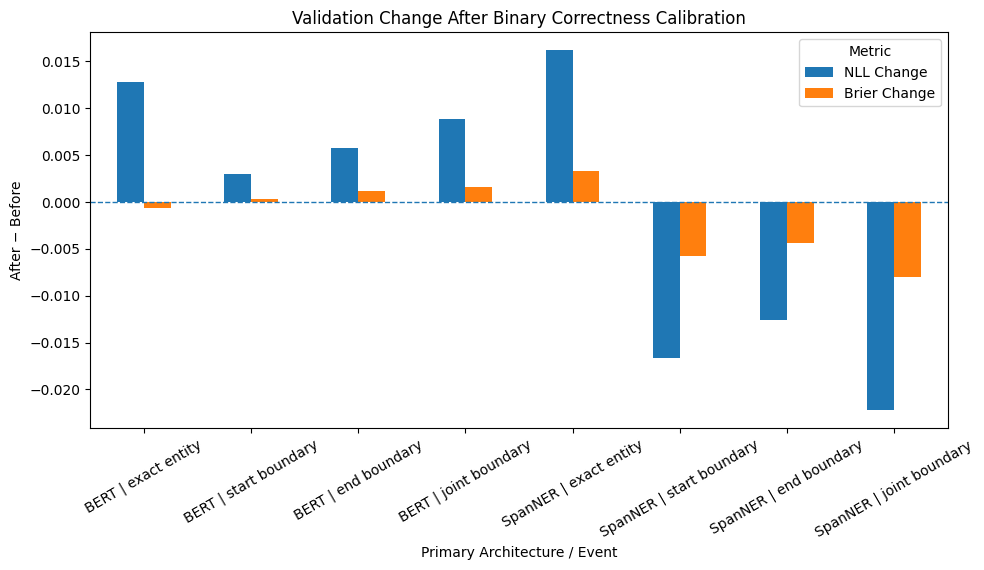

In [99]:
adoption_plot_df = (
    primary_validation_improvement_df[
        [
            "Model",
            "Event",
            "NLL Change",
            "Brier Change",
        ]
    ]
    .copy()
)

adoption_plot_df[
    "Configuration"
] = (
    adoption_plot_df[
        "Model"
    ]
    + " | "
    + adoption_plot_df[
        "Event"
    ].str.replace(
        "_",
        " ",
    )
)

adoption_plot_df = (
    adoption_plot_df
    .set_index(
        "Configuration"
    )[
        [
            "NLL Change",
            "Brier Change",
        ]
    ]
)


ax = adoption_plot_df.plot(
    kind="bar",
    figsize=(10, 5.8),
)

ax.axhline(
    0.0,
    linestyle="--",
    linewidth=1.0,
)

ax.set_title(
    "Validation Change After Binary Correctness Calibration"
)

ax.set_xlabel(
    "Primary Architecture / Event"
)

ax.set_ylabel(
    "After − Before"
)

ax.tick_params(
    axis="x",
    rotation=30,
)

ax.legend(
    title="Metric"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "primary_binary_calibration_validation_changes.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 9. Final Recommended Calibration Outputs

The calibration pipeline is now frozen.

Temperature scaling is retained for both architectures because it improved independent-validation probability calibration while preserving all predicted classes.

Binary correctness calibration is applied selectively according to the pre-specified validation adoption rule. Of the eight primary configurations, three are adopted:

- Span model start-boundary competition;
- Span model end-boundary competition;
- Span model joint-boundary competition.

For these configurations, the fitted logistic probability is retained as the recommended correctness value.

For BERT exact-entity and boundary scores, and for Span model exact-entity confidence, binary calibration is rejected because independent-validation NLL and Brier score did not both improve. Their temperature-scaled or derived architecture-native scores are therefore retained.

This distinction is important: a score may discriminate errors effectively without itself benefiting from an additional probabilistic calibration mapping.

The recommended prediction-level registry exported below records both the underlying raw score and the fitted binary probability, together with the validation-based decision identifying which value is permitted downstream.

## 9.1 Adopted Primary Binary Calibrators

In [100]:
adopted_primary_calibrators_df = (
    primary_recommendations_df.loc[
        primary_recommendations_df[
            "Binary Calibration Adopted"
        ].eq(True)
    ]
    .reset_index(
        drop=True
    )
)


adopted_primary_calibrators_df.to_csv(
    CONFIG_DIR
    / "adopted_primary_binary_calibrators.csv",
    index=False,
)


print(
    "Adopted primary binary correctness calibrators:"
)

display(
    adopted_primary_calibrators_df[
        [
            "Calibrator ID",
            "Model",
            "Event",
            "Primary Score",
            "Population Policy",
            "Validation NLL Change",
            "Validation Brier Change",
            "Validation ECE Change",
        ]
    ].round(
        6
    )
)

Adopted primary binary correctness calibrators:


,Calibrator ID,Model,Event,Primary Score,Population Policy,Validation NLL Change,Validation Brier Change,Validation ECE Change
0,spanner_start_competition,SpanNER,start_boundary,Start boundary competition confidence,competitor_available_matched_pairs,-0.016687,-0.005802,-0.021877
1,spanner_end_competition,SpanNER,end_boundary,End boundary competition confidence,competitor_available_matched_pairs,-0.012622,-0.004371,-0.015662
2,spanner_joint_competition,SpanNER,joint_boundary,Joint boundary competition confidence,competitor_available_matched_pairs,-0.022190,-0.007981,-0.027463


## 9.2 Export Recommended Prediction-Level Values

In [101]:
recommendation_lookup_df = (
    primary_recommendations_df[
        [
            "Calibrator ID",
            "Binary Calibration Adopted",
            "Recommended Stage",
        ]
    ]
    .copy()
)


recommended_primary_predictions_df = (
    binary_calibrated_predictions_df.loc[
        binary_calibrated_predictions_df[
            "Analysis Role"
        ].eq(
            "primary"
        )
    ]
    .merge(
        recommendation_lookup_df,
        on="Calibrator ID",
        how="left",
        validate="many_to_one",
    )
)


if (
    recommended_primary_predictions_df[
        "Binary Calibration Adopted"
    ]
    .isna()
    .any()
):
    raise RuntimeError(
        "Missing recommendation decision for a primary configuration."
    )


recommended_primary_predictions_df[
    "Recommended Correctness Value"
] = np.where(
    recommended_primary_predictions_df[
        "Binary Calibration Adopted"
    ],
    recommended_primary_predictions_df[
        "Binary Calibrated Correctness Probability"
    ],
    recommended_primary_predictions_df[
        "Raw Score"
    ],
)


recommended_primary_predictions_df[
    "Recommended Value Is Calibrated Probability"
] = (
    recommended_primary_predictions_df[
        "Binary Calibration Adopted"
    ]
    .astype(bool)
)


recommended_primary_predictions_df.to_csv(
    CALIBRATED_PREDICTION_DIR
    / "recommended_primary_prediction_values.csv",
    index=False,
)


recommended_value_summary_df = (
    recommended_primary_predictions_df
    .groupby(
        [
            "Model",
            "Event",
            "Population",
            "Recommended Stage",
            "Recommended Value Is Calibrated Probability",
        ],
        as_index=False,
    )
    .agg(
        Rows=(
            "Target Correct",
            "size",
        ),
        Correct=(
            "Target Correct",
            "sum",
        ),
        Errors=(
            "Target Correct",
            lambda values: int(
                len(values)
                - values.sum()
            ),
        ),
        Mean_Recommended_Value=(
            "Recommended Correctness Value",
            "mean",
        ),
        Minimum_Recommended_Value=(
            "Recommended Correctness Value",
            "min",
        ),
        Maximum_Recommended_Value=(
            "Recommended Correctness Value",
            "max",
        ),
    )
)


print(
    "Recommended primary prediction values:"
)

display(
    recommended_value_summary_df.round(
        6
    )
)

Recommended primary prediction values:


,Model,Event,Population,Recommended Stage,Recommended Value Is Calibrated Probability,Rows,Correct,Errors,Mean_Recommended_Value,Minimum_Recommended_Value,Maximum_Recommended_Value
0,BERT,end_boundary,probability_calibration,temperature_scaled_or_derived_score,False,1734,1716,18,0.997783,0.619847,1.000000
1,BERT,end_boundary,validation,temperature_scaled_or_derived_score,False,2981,2952,29,0.997689,0.526803,1.000000
2,BERT,exact_entity,probability_calibration,temperature_scaled_or_derived_score,False,1771,1652,119,0.961640,0.275453,0.996929
3,BERT,exact_entity,validation,temperature_scaled_or_derived_score,False,3039,2859,180,0.960307,0.230694,0.996759
4,BERT,joint_boundary,probability_calibration,temperature_scaled_or_derived_score,False,1734,1703,31,0.990112,0.002525,0.999482
5,BERT,joint_boundary,validation,temperature_scaled_or_derived_score,False,2981,2931,50,0.991414,0.008047,0.999475
6,BERT,start_boundary,probability_calibration,temperature_scaled_or_derived_score,False,1734,1720,14,0.991879,0.002525,0.999482
7,BERT,start_boundary,validation,temperature_scaled_or_derived_score,False,2981,2958,23,0.993328,0.008047,0.999475
8,SpanNER,end_boundary,probability_calibration,binary_calibrated_probability,True,1711,1696,15,0.991233,0.833127,0.994131
9,SpanNER,end_boundary,validation,binary_calibrated_probability,True,2921,2907,14,0.991647,0.812691,0.994131


## 9.3 Final Calibration Decision Table

In [102]:
final_calibration_decision_df = (
    primary_recommendations_df[
        [
            "Model",
            "Event",
            "Primary Score",
            "Population Policy",
            "Binary Calibration Adopted",
            "Recommended Stage",
            "Validation NLL Change",
            "Validation Brier Change",
            "Validation ECE Change",
        ]
    ]
    .copy()
)


final_calibration_decision_df[
    "Decision"
] = np.where(
    final_calibration_decision_df[
        "Binary Calibration Adopted"
    ],
    "Adopt binary calibration",
    "Retain temperature-scaled / derived score",
)


final_calibration_decision_df.to_csv(
    METRICS_DIR
    / "final_primary_calibration_decisions.csv",
    index=False,
)


print(
    "Final primary calibration decisions:"
)

display(
    final_calibration_decision_df[
        [
            "Model",
            "Event",
            "Primary Score",
            "Decision",
            "Validation NLL Change",
            "Validation Brier Change",
            "Validation ECE Change",
        ]
    ].round(
        6
    )
)

Final primary calibration decisions:


,Model,Event,Primary Score,Decision,Validation NLL Change,Validation Brier Change,Validation ECE Change
0,BERT,exact_entity,Geometric BIO span confidence,Retain temperature-scaled / derived score,0.012762,-0.000592,0.008887
1,BERT,start_boundary,BIO start-boundary confidence,Retain temperature-scaled / derived score,0.002995,0.000283,-0.001547
2,BERT,end_boundary,BIO end-stopping confidence,Retain temperature-scaled / derived score,0.005717,0.001208,-0.003750
3,BERT,joint_boundary,Joint BIO boundary confidence,Retain temperature-scaled / derived score,0.008848,0.001556,-0.005636
4,SpanNER,exact_entity,Direct span probability,Retain temperature-scaled / derived score,0.016185,0.003258,0.017037
5,SpanNER,start_boundary,Start boundary competition confidence,Adopt binary calibration,-0.016687,-0.005802,-0.021877
6,SpanNER,end_boundary,End boundary competition confidence,Adopt binary calibration,-0.012622,-0.004371,-0.015662
7,SpanNER,joint_boundary,Joint boundary competition confidence,Adopt binary calibration,-0.022190,-0.007981,-0.027463


###  Appendix Figure: Reliability diagrams

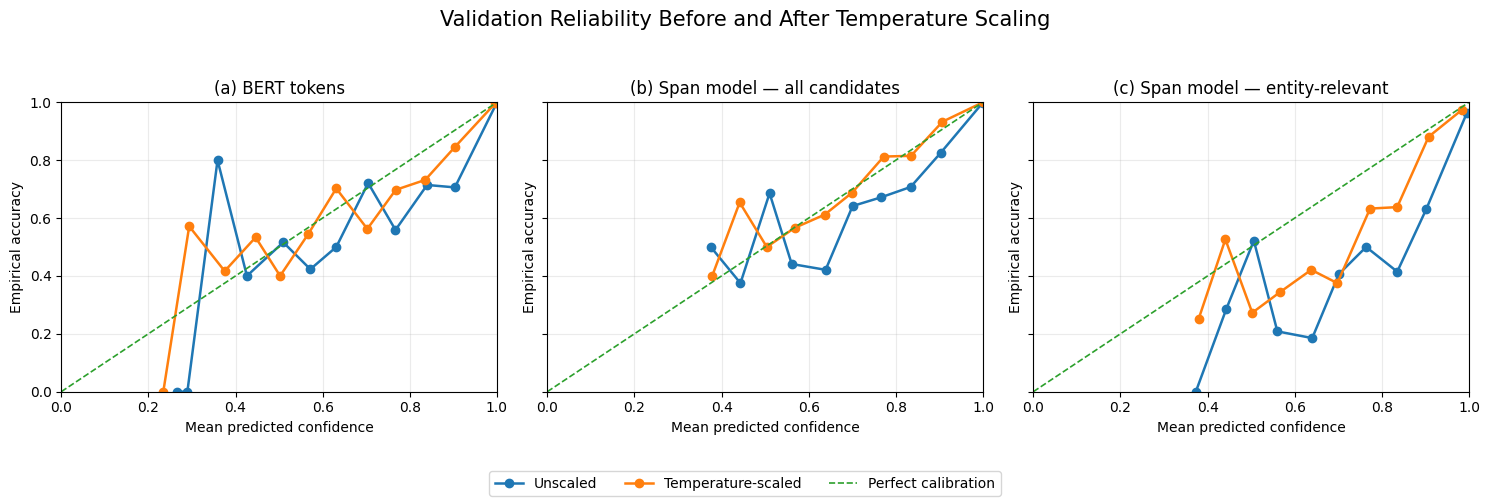

Saved: /kaggle/working/04_probability_and_boundary_calibration/figures/temperature_scaling_reliability_diagrams.png


In [108]:
# Appendix Figure:
# Validation Reliability Diagrams Before and After
# Temperature Scaling

import matplotlib.pyplot as plt
import pandas as pd


# 1. Pull the reliability tables already computed in Notebook 04

# BERT validation tokens
bert_before = (
    bert_reliability_tables["validation"]["unscaled"]
    .copy()
)

bert_after = (
    bert_reliability_tables["validation"]["temperature_scaled"]
    .copy()
)


# Span model — all candidates
span_all_before = (
    spanner_reliability_tables["validation"]["all_candidates"]["unscaled"]
    .copy()
)

span_all_after = (
    spanner_reliability_tables["validation"]["all_candidates"]["temperature_scaled"]
    .copy()
)


# Span model — entity-relevant candidates
span_entity_before = (
    spanner_reliability_tables["validation"]["entity_relevant"]["unscaled"]
    .copy()
)

span_entity_after = (
    spanner_reliability_tables["validation"]["entity_relevant"]["temperature_scaled"]
    .copy()
)


# 2. Keep only non-empty bins


def nonempty_bins(df):
    return (
        df.loc[df["count"] > 0]
        .sort_values("mean_confidence")
        .copy()
    )


bert_before = nonempty_bins(bert_before)
bert_after = nonempty_bins(bert_after)

span_all_before = nonempty_bins(span_all_before)
span_all_after = nonempty_bins(span_all_after)

span_entity_before = nonempty_bins(span_entity_before)
span_entity_after = nonempty_bins(span_entity_after)


# 3. Plot helper

def plot_reliability(
    ax,
    before_df,
    after_df,
    title,
):

    ax.plot(
        before_df["mean_confidence"],
        before_df["accuracy"],
        marker="o",
        linewidth=1.8,
        label="Unscaled",
    )

    ax.plot(
        after_df["mean_confidence"],
        after_df["accuracy"],
        marker="o",
        linewidth=1.8,
        label="Temperature-scaled",
    )

    # Ideal calibration
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        linewidth=1.2,
        label="Perfect calibration",
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xlabel(
        "Mean predicted confidence"
    )

    ax.set_ylabel(
        "Empirical accuracy"
    )

    ax.set_title(
        title
    )

    ax.grid(
        alpha=0.25
    )


# 4. Create three-panel appendix figure

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharex=True,
    sharey=True,
)


plot_reliability(
    axes[0],
    bert_before,
    bert_after,
    "(a) BERT tokens",
)

plot_reliability(
    axes[1],
    span_all_before,
    span_all_after,
    "(b) Span model — all candidates",
)

plot_reliability(
    axes[2],
    span_entity_before,
    span_entity_after,
    "(c) Span model — entity-relevant",
)


# One shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=True,
)


fig.suptitle(
    "Validation Reliability Before and After Temperature Scaling",
    fontsize=15,
)


plt.tight_layout(
    rect=[0, 0.10, 1, 0.94]
)


# 5. Save figure

reliability_figure_path = (
    FIGURE_DIR
    / "temperature_scaling_reliability_diagrams.png"
)

plt.savefig(
    reliability_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved:",
    reliability_figure_path,
)

In [105]:
# ============================================================
# Save multiclass reliability-bin artefacts
# ============================================================

reliability_export_tables = []


def prepare_export(
    df,
    model,
    population,
    calibration_state,
):
    export_df = df.copy()

    export_df.insert(
        0,
        "Calibration State",
        calibration_state,
    )

    export_df.insert(
        0,
        "Population",
        population,
    )

    export_df.insert(
        0,
        "Model",
        model,
    )

    return export_df


reliability_export_tables.extend([
    prepare_export(
        bert_reliability_tables["validation"]["unscaled"],
        "BERT",
        "all_valid_original_tokens",
        "unscaled",
    ),

    prepare_export(
        bert_reliability_tables["validation"]["temperature_scaled"],
        "BERT",
        "all_valid_original_tokens",
        "temperature_scaled",
    ),

    prepare_export(
        spanner_reliability_tables["validation"]["all_candidates"]["unscaled"],
        "Span model",
        "all_candidates",
        "unscaled",
    ),

    prepare_export(
        spanner_reliability_tables["validation"]["all_candidates"]["temperature_scaled"],
        "Span model",
        "all_candidates",
        "temperature_scaled",
    ),

    prepare_export(
        spanner_reliability_tables["validation"]["entity_relevant"]["unscaled"],
        "Span model",
        "entity_relevant",
        "unscaled",
    ),

    prepare_export(
        spanner_reliability_tables["validation"]["entity_relevant"]["temperature_scaled"],
        "Span model",
        "entity_relevant",
        "temperature_scaled",
    ),
])


validation_multiclass_reliability_bins_df = pd.concat(
    reliability_export_tables,
    ignore_index=True,
)


validation_multiclass_reliability_bins_df.to_csv(
    RELIABILITY_DIR
    / "validation_multiclass_temperature_reliability_bins.csv",
    index=False,
)


print(
    "Saved reliability-bin table:",
    RELIABILITY_DIR
    / "validation_multiclass_temperature_reliability_bins.csv",
)

Saved reliability-bin table: /kaggle/working/04_probability_and_boundary_calibration/reliability_bins/validation_multiclass_temperature_reliability_bins.csv


## 9.4 Freeze the Downstream Calibration Specification

In [106]:
downstream_calibration_specification = {
    "status": (
        "PROBABILITY_AND_BOUNDARY_CALIBRATION_FROZEN"
    ),

    "probability_calibration_sentences": 975,
    "validation_sentences": 1625,

    "temperature_scaling": {
        "BERT": {
            "temperature": float(
                bert_temperature
            ),
            "adopted": True,
        },

        "SpanNER": {
            "temperature": float(
                spanner_temperature
            ),
            "adopted": True,
        },
    },

    "primary_binary_calibration": {
        row[
            "Calibrator ID"
        ]: {
            "model": (
                row[
                    "Model"
                ]
            ),
            "event": (
                row[
                    "Event"
                ]
            ),
            "score": (
                row[
                    "Primary Score"
                ]
            ),
            "population_policy": (
                row[
                    "Population Policy"
                ]
            ),
            "binary_calibration_adopted": bool(
                row[
                    "Binary Calibration Adopted"
                ]
            ),
            "recommended_stage": (
                row[
                    "Recommended Stage"
                ]
            ),
        }

        for row in (
            primary_recommendations_df
            .to_dict(
                orient="records"
            )
        )
    },

    "adopted_primary_binary_calibrators": (
        adopted_primary_calibrators_df[
            "Calibrator ID"
        ]
        .tolist()
    ),

    "number_primary_configurations": int(
        len(
            primary_recommendations_df
        )
    ),

    "number_primary_binary_calibrations_adopted": int(
        primary_recommendations_df[
            "Binary Calibration Adopted"
        ].sum()
    ),

    "adoption_rule": (
        "validation NLL and Brier must both improve"
    ),

    "missing_spanner_competition_imputed": False,
    "validation_used_for_parameter_fitting": False,
    "conformal_calibration_accessed": False,
    "official_test_accessed": False,

    "next_notebook": (
        "05_Conformal_Prediction_and_M1_M4"
    ),
}


with open(
    CONFIG_DIR
    / "downstream_calibration_specification.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        downstream_calibration_specification,
        file,
        indent=4,
    )


print(
    "Downstream calibration specification frozen."
)

print(
    "Primary configurations:",
    len(
        primary_recommendations_df
    ),
)

print(
    "Primary binary calibrations adopted:",
    int(
        primary_recommendations_df[
            "Binary Calibration Adopted"
        ].sum()
    ),
)

print(
    "Adopted calibrators:",
    adopted_primary_calibrators_df[
        "Calibrator ID"
    ].tolist(),
)

Downstream calibration specification frozen.
Primary configurations: 8
Primary binary calibrations adopted: 3
Adopted calibrators: ['spanner_start_competition', 'spanner_end_competition', 'spanner_joint_competition']


## 9.5 Notebook Completion Record

In [107]:
completion_record = {
    "notebook": (
        "04_Probability_and_Boundary_Calibration"
    ),

    "status": (
        "complete"
    ),

    "probability_calibration_sentences": 975,
    "validation_sentences": 1625,

    "bert_temperature": float(
        bert_temperature
    ),

    "spanner_temperature": float(
        spanner_temperature
    ),

    "temperature_scaling_fitted": True,

    "binary_calibrators_fitted": int(
        len(
            calibrator_registry_df
        )
    ),

    "primary_binary_configurations": int(
        len(
            primary_recommendations_df
        )
    ),

    "primary_binary_calibrations_adopted": int(
        primary_recommendations_df[
            "Binary Calibration Adopted"
        ].sum()
    ),

    "adopted_primary_calibrator_ids": (
        adopted_primary_calibrators_df[
            "Calibrator ID"
        ]
        .tolist()
    ),

    "natural_class_distribution_preserved": True,
    "natural_event_prevalence_preserved": True,

    "class_weighting_used": False,
    "resampling_for_fitting_used": False,
    "synthetic_errors_used": False,
    "missing_competitor_imputation_used": False,

    "validation_used_for_fitting": False,

    "model_retraining_performed": False,
    "new_neural_inference_performed": False,
    "decoder_rerun": False,
    "matching_rerun": False,

    "conformal_prediction_fitted": False,
    "conformal_calibration_accessed": False,
    "official_test_accessed": False,

    "next_notebook": (
        "05_Conformal_Prediction_and_M1_M4"
    ),
}


with open(
    OUTPUT_DIR
    / "completion_record.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        completion_record,
        file,
        indent=4,
    )


print(
    "NOTEBOOK 04 — PROBABILITY AND BOUNDARY CALIBRATION COMPLETE"
)

print(
    "BERT temperature:",
    round(
        bert_temperature,
        6,
    ),
)

print(
    "SpanNER temperature:",
    round(
        spanner_temperature,
        6,
    ),
)

print(
    "Primary binary calibrations adopted:",
    completion_record[
        "primary_binary_calibrations_adopted"
    ],
)

print(
    "Conformal prediction fitted:",
    False,
)

print(
    "Official test accessed:",
    False,
)

print(
    "Next notebook:",
    completion_record[
        "next_notebook"
    ],
)

NOTEBOOK 04 — PROBABILITY AND BOUNDARY CALIBRATION COMPLETE
BERT temperature: 1.264385
SpanNER temperature: 1.466519
Primary binary calibrations adopted: 3
Conformal prediction fitted: False
Official test accessed: False
Next notebook: 05_Conformal_Prediction_and_M1_M4


## Notebook Summary

This notebook completes probability and boundary-correctness calibration for the frozen BERT BIO and SpanNER branches.

Multiclass temperature scaling was fitted exclusively on the 975-sentence probability-calibration population. The fitted temperatures were 1.2644 for BERT and 1.4665 for SpanNER.. Applying these temperatures to the independent validation population preserved all predicted classes while improving NLL, Brier score and ECE for both architectures.

The scaled probabilities were propagated to the frozen entity predictions without re-decoding. BERT retained its geometric typed-span confidence and BIO-derived start, end and joint-boundary signals. Span model retained direct span probability and candidate-local start, end and joint boundary competition, with structurally unavailable competitor values left missing.

Separate one-dimensional logistic mappings were then fitted for exact-entity, start-boundary, end-boundary and joint-boundary correctness. All eight primary calibrators fitted with positive slopes and without convergence failures.

The pre-specified validation adoption rule required both NLL and Brier score to improve. Under this rule, **none of the four BERT binary mappings were adopted**, and **Span model exact-entity calibration was also rejected**. In contrast, the **Span model start, end and joint boundary-competition calibrators were adopted**, with validation NLL and Brier improvements supported by sentence-cluster bootstrap intervals that remained below zero.

These findings distinguish error discrimination from probability calibration. A score can rank errors effectively without an additional logistic mapping improving its probabilistic reliability.

The resulting downstream registry therefore retains temperature-scaled or architecture-derived values for the rejected configurations and binary-calibrated correctness probabilities for the three adopted Span model boundary configurations.

No conformal threshold was fitted and the official CoNLL-2003 test population was not accessed. The next notebook performs conformal prediction using the now-frozen calibration specification.